# 📣 Stage 5 — ANOVA, Chi-Square & Non-Parametric Tests
## Marketing Channel Performance Analysis — Complete Jupyter Notebook

---

> 📌 **Tamil:** "3+ groups compare பண்ண ANOVA, categorical data-க்கு Chi-square,  
> normal distribution இல்லாத data-க்கு non-parametric tests.  
> இந்த notebook-ல் marketing channel budget allocation decision எடுக்கணும்."

---

முன்னைய Stage-களில்:

t-test → 2 groups compare, 
Z-test → proportions compare

ஆனால் business-ல்:

4 marketing channels, 
5 product categories, 
6 regions

போன்ற பல groups இருக்கும். அப்போது ANOVA, Chi-Square, Kruskal-Wallis போன்ற tests பயன்படுத்த வேண்டும்.

---

CTR(Click-Through Rate)= Clicks / Impressions ×100
| Term        | Meaning                             |
| ----------- | ----------------------------------- |
| Impressions | Ad எத்தனை முறை காட்டப்பட்டது        |
| Clicks      | Ad-ஐ எத்தனை பேர் கிளிக் செய்தார்கள் |
| CTR         | Click percentage                    |

---

| தலைப்பு                          | வரையறை (Define)                                                | எப்போது பயன்படுத்த வேண்டும்? | உதாரணம்                                      | Hypothesis                  | Result Meaning                        | Business பயன்பாடு                            |
| -------------------------------- | -------------------------------------------------------------- | ---------------------------- | -------------------------------------------- | --------------------------- | ------------------------------------- | -------------------------------------------- |
| **Shapiro-Wilk Test**            | Data normal distribution-ஐ பின்பற்றுகிறதா எனச் சோதிக்கும் test | ANOVA/T-test முன்            | Google Ads order values normal-ஆ?            | H₀: Data normal             | p > 0.05 → Normal                     | எந்த test பயன்படுத்துவது என்பதை முடிவு செய்ய |
| **Levene Test**                  | Groups variance சமமாக உள்ளதா எனச் சோதிக்கும்                   | ANOVA முன்                   | Google, Facebook, Instagram variance same-ஆ? | H₀: Variances equal         | p > 0.05 → Equal variance             | Standard ANOVA பயன்படுத்தலாம்                |
| **Bartlett Test**                | Variance equality test                                         | Data normal என்றால்          | 4 channel variance compare                   | H₀: Variances equal         | p > 0.05 → Equal                      | Levene-க்கு alternative                      |
| **One-Way ANOVA**                | 3+ groups mean compare                                         | Normal data                  | 4 marketing channels order value compare     | H₀: All means equal         | p < 0.05 → At least one group differs | Best marketing channel கண்டுபிடிக்க          |
| **Welch ANOVA**                  | Unequal variance இருக்கும் போது ANOVA                          | Normal but unequal variance  | Ad CTR compare                               | H₀: All means equal         | p < 0.05 → Difference exists          | Robust ANOVA                                 |
| **Tukey HSD**                    | ANOVA பிறகு எந்த groups வேறுபடுகிறது என கண்டுபிடிக்கும்        | ANOVA significant என்றால்    | Instagram vs Facebook                        | H₀: Pair means equal        | Reject → Significant difference       | Budget allocation                            |
| **Games-Howell**                 | Welch ANOVA post-hoc test                                      | Unequal variance             | Video A vs Banner B                          | H₀: Pair means equal        | Reject → Difference                   | Ad creative selection                        |
| **Kruskal-Wallis Test**          | ANOVA-வின் non-parametric version                              | Non-normal data, 3+ groups   | Product ratings compare                      | H₀: All distributions equal | p < 0.05 → Difference exists          | Category performance                         |
| **Mann-Whitney U Test**          | t-test-ன் non-parametric version                               | Non-normal, 2 groups         | Electronics vs Books ratings                 | H₀: Same distribution       | p < 0.05 → Different                  | Pairwise comparison                          |
| **Chi-Square Test**              | இரண்டு categorical variables தொடர்பு உள்ளதா?                   | Categorical data             | Region vs Subscription Tier                  | H₀: Independent             | p < 0.05 → Related                    | Customer segmentation                        |
| **Chi-Square Contingency Table** | Frequency table analysis                                       | Chi-Square input             | Region × Tier counts                         | H₀: Independent             | High χ² → Strong relationship         | Regional strategy                            |
| **Multiple Testing Correction**  | பல p-values correction                                         | Many pairwise tests          | 10 category comparisons                      | H₀ varies                   | Adjusted p-value                      | False positive குறைக்க                       |


---

### 5 Projects in this Notebook

| # | Project | Dataset | Tests Used | Business Question |
|---|---------|---------|-----------|-------------------|
| 1 | Marketing channels | `marketing_channels.csv` | Shapiro-Wilk → ANOVA → Tukey HSD | Which channel drives highest order value? |
| 2 | Product ratings | `product_ratings.csv` | Kruskal-Wallis → Mann-Whitney U | Do ratings differ across product categories? |
| 3 | Customer segments | `customer_segments.csv` | Chi-square independence | Does region affect subscription tier? |
| 4 | Ad campaign CTR | `ad_campaigns.csv` | Welch ANOVA → Games-Howell | Which ad creative gets best CTR? |
| 5 | Sales by region | `regional_sales.csv` | Full pipeline | Regional budget reallocation decision |

---

## ⚙️ Step 0 — Imports & Helper Functions

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import (shapiro, f_oneway, kruskal, mannwhitneyu,
                          chi2_contingency, levene, bartlett)
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Palette ──────────────────────────────────────────────────────────────────
PURPLE='#534AB7'; TEAL='#0F6E56'; AMBER='#BA7517'
CORAL='#993C1D'; BLUE='#185FA5'; DGRAY='#5F5E5A'; GREEN='#3B6D11'
COLORS = [PURPLE, TEAL, AMBER, CORAL, BLUE, GREEN, DGRAY]

plt.rcParams.update({
    'figure.facecolor':'#FAFAFA','axes.facecolor':'#FFFFFF',
    'axes.grid':True,'grid.alpha':0.25,'grid.linestyle':'--',
    'font.family':'DejaVu Sans',
    'axes.spines.top':False,'axes.spines.right':False,
})

# ══════════════════════════════════════════════════════════
#  REUSABLE HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════

def normality_check(groups_dict, n_sample=50):
    """Run Shapiro-Wilk on each group. Returns summary DataFrame."""
    rows = []
    for name, data in groups_dict.items():
        sample = data[:n_sample] if len(data) > n_sample else data
        stat, p = shapiro(sample)
        rows.append({'Group':name,'n':len(data),
                     'Mean':round(data.mean(),2),'Std':round(data.std(),2),
                     'W-stat':round(stat,4),'p-value':round(p,4),
                     'Normal?':'Yes' if p>0.05 else 'No'})
    return pd.DataFrame(rows).set_index('Group')

def run_anova(groups_dict, alpha=0.05):
    """One-way ANOVA + effect size (eta-squared)."""
    groups = list(groups_dict.values())
    F, p   = f_oneway(*groups)
    # eta-squared
    grand_mean = np.concatenate(groups).mean()
    ss_between = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups)
    ss_total   = sum(((g - grand_mean)**2).sum() for g in groups)
    eta2 = ss_between / ss_total
    k    = len(groups)
    N    = sum(len(g) for g in groups)
    return {'F':F,'p':p,'eta2':eta2,'k':k,'N':N,
            'df_between':k-1,'df_within':N-k,
            'significant':p<alpha}

def print_anova(result, name='ANOVA'):
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  F-statistic    : {result['F']:.4f}")
    print(f"  df (between)   : {result['df_between']}")
    print(f"  df (within)    : {result['df_within']}")
    print(f"  p-value        : {result['p']:.6f}")
    print(f"  eta-squared    : {result['eta2']:.4f}  "
          f"({'small' if result['eta2']<0.06 else 'medium' if result['eta2']<0.14 else 'large'} effect)")
    sig = result['significant']
    print(f"  Decision       : {'REJECT H0 — at least one group differs' if sig else 'Fail to reject H0'}")

def cohens_d(a, b):
    """Effect size for two groups."""
    pooled = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return abs(a.mean() - b.mean()) / pooled if pooled > 0 else 0

print("All imports and helper functions ready!")
print("  normality_check()  — Shapiro-Wilk for all groups")
print("  run_anova()        — F-stat, p-value, eta-squared")
print("  print_anova()      — formatted output")
print("  cohens_d()         — effect size between two groups")

# | Function             | Use                   | Example                                    |
# | -------------------- | --------------------- | ------------------------------------------ |
# | `shapiro()`          | Normality Test        | Data normal distribution follow செய்கிறதா? |
# | `f_oneway()`         | One-way ANOVA         | 3+ groups mean compare                     |
# | `kruskal()`          | Non-parametric ANOVA  | Normal இல்லாத data                         |
# | `mannwhitneyu()`     | Non-parametric t-test | 2 groups compare                           |
# | `chi2_contingency()` | Chi-Square Test       | Categorical relationship                   |
# | `levene()`           | Equal variance test   | Variance same ஆ?                           |
# | `bartlett()`         | Equal variance test   | Another variance test                      |



All imports and helper functions ready!
  normality_check()  — Shapiro-Wilk for all groups
  run_anova()        — F-stat, p-value, eta-squared
  print_anova()      — formatted output
  cohens_d()         — effect size between two groups


---
---
# 📣 Project 1 — Marketing Channel Performance
## One-Way ANOVA + Tukey HSD Post-Hoc

---

### Business Problem
A D2C brand spends ₹50L/month across 4 marketing channels.  
The CMO asks: *Does the acquisition channel significantly affect average order value (AOV)?  
Which channels are meaningfully different so we can reallocate the budget?*

> 📌 **Tamil:** "4 marketing channels compare பண்றோம் — ANOVA overall significance காட்டுகிறது.  
> Tukey HSD எந்த specific pair different என்று காட்டுகிறது."

---

🎯 பிரச்சனை என்ன?

ஒரு Online Shopping Company (D2C Brand) மாதம் ₹50 லட்சம் செலவு செய்கிறது.

அவர்கள் 4 Marketing Channels பயன்படுத்துகிறார்கள்:

Channel : 
Facebook Ads, 
Google Ads, 
Instagram Ads, 
Email Marketing

Company-க்கு ஒரு கேள்வி:

"எந்த Marketing Channel மூலம் வரும் Customers அதிகமாக Order Value (AOV - Average Order Value) செலவு செய்கிறார்கள்?"


### Why ANOVA and not 3 separate t-tests?
Running 3 t-tests → P(at least 1 false positive) = 1−(0.95)³ = 14% !  
ANOVA keeps the family-wise error rate at exactly α = 5%.

---

❌ ஏன் 3 t-Test போடக்கூடாது?

நமக்கு 4 groups இருக்கிறது.

Compare செய்ய:
Facebook vs Google, 
Facebook vs Instagram, 
Facebook vs Email

3 t-tests run பண்ணலாம்.

ஆனா ஒரு பிரச்சனை இருக்கு.

False Positive

உண்மையில் Difference இல்லாதபோதும்

Test:

"Difference இருக்கு"

என்று தவறாக சொல்லலாம்.

இதைத்தான் False Positive சொல்வோம்.

✅ அதனால் ANOVA பயன்படுத்துகிறோம்

ANOVA ஒரே Test-ல்
4 Groups-யும் Compare செய்கிறது.
Error Rate: 5% ஆகவே இருக்கும்.

---

### Test Pipeline
```
1. Shapiro-Wilk normality  →  is ANOVA valid?
2. Levene test             →  equal variances?
3. One-way ANOVA           →  any group differs?
4. Tukey HSD post-hoc      →  which specific pairs?
5. Effect size (eta²)      →  how big is the difference?
6. Business decision       →  reallocate budget
```

---

Shapiro
   ↓
Data Normal ஆ?

Levene
   ↓
Variance Same ஆ?

ANOVA
   ↓
Any Difference இருக்கா?

Tukey
   ↓
யார் Different?

Eta²
   ↓
Difference இருக்கிறது. ஆனா Difference எவ்வளவு பெரியது?, சிறிய Difference ஆ?

Business Decision
   ↓
Budget எங்கு போடலாம்?

---

| Eta²      | Meaning |
| --------- | ------- |
| <0.06     | Small   |
| 0.06-0.14 | Medium  |
| >0.14     | Large   |

Eta² = 0.25

Meaning: 25% variation Marketing Channel காரணமாக வருகிறது. ✅ Large Effect

In [ ]:
# Marketing Channel Dataset
# "Email, Social Media, Paid Ads, SEO மூலம் வந்த Customers எப்படி Order செய்கிறார்கள்?" என்ற மாதிரி ஒரு Fake Business Dataset உருவாக்குகிறது.

np.random.seed(42)
n = 200   # customers per channel

# Order values (₹) by acquisition channel
email  = np.random.normal(loc=850,  scale=200, size=n)
social = np.random.normal(loc=920,  scale=220, size=n)
paid   = np.random.normal(loc=1050, scale=250, size=n)
seo    = np.random.normal(loc=880,  scale=180, size=n)

channels = {'Email':email, 'Social Media':social,
            'Paid Ads':paid, 'SEO':seo}

# Build complete dataset with metadata
records = []
for ch, vals in channels.items():
    for v in vals:
        records.append({
            'customer_id'   : f'C{len(records)+1:05d}',
            'channel'       : ch,
            'order_value'   : round(v, 2),
            'is_repeat'     : np.random.choice([0,1], p=[0.6,0.4]),
            'device'        : np.random.choice(['Mobile','Desktop','Tablet'],
                                               p=[0.58,0.34,0.08]),
            'city_tier'     : np.random.choice(['Tier1','Tier2','Tier3'],
                                               p=[0.40,0.38,0.22]),
        })

df_mkt = pd.DataFrame(records)
df_mkt.to_csv('marketing_channels.csv', index=False)
print(f"Dataset saved: marketing_channels.csv")
print(f"  {len(df_mkt):,} rows x {df_mkt.shape[1]} columns")
df_mkt.head(8)

# | Column          | Full Meaning              | தமிழ் விளக்கம்                                                  | Example                                          |
# | --------------- | ------------------------- | --------------------------------------------------------------- | ------------------------------------------------ |
# | **customer_id** | Customer Unique ID        | ஒவ்வொரு வாடிக்கையாளருக்கும் கொடுக்கப்படும் தனிப்பட்ட அடையாள எண் | C00001, C00025                                   |
# | **channel**     | Marketing Channel         | வாடிக்கையாளர் எந்த விளம்பர/மார்க்கெட்டிங் வழி மூலம் வந்தார்     | Email, Social Media, Paid Ads, SEO               |
# | **order_value** | Order Amount              | வாடிக்கையாளர் ஒரு ஆர்டருக்கு செலவழித்த தொகை                     | ₹850, ₹1200, ₹950                                |
# | **is_repeat**   | Repeat Customer Indicator | வாடிக்கையாளர் மீண்டும் வாங்கியவரா என்பதை காட்டும்               | 0 = புதிய வாடிக்கையாளர், 1 = மீண்டும் வாங்கியவர் |
# | **device**      | Device Used               | வாடிக்கையாளர் எந்த சாதனத்தை பயன்படுத்தி வாங்கினார்              | Mobile, Desktop, Tablet                          |
# | **city_tier**   | City Category             | வாடிக்கையாளர் வசிக்கும் நகரத்தின் வகை                           | Tier1, Tier2, Tier3                              |


Dataset saved: marketing_channels.csv
  800 rows x 6 columns


,customer_id,channel,order_value,is_repeat,device,city_tier
0,C00001,Email,949.34,0,Desktop,Tier1
1,C00002,Email,822.35,0,Mobile,Tier1
2,C00003,Email,979.54,0,Desktop,Tier1
3,C00004,Email,1154.61,1,Mobile,Tier1
4,C00005,Email,803.17,0,Desktop,Tier1
5,C00006,Email,803.17,1,Desktop,Tier2
6,C00007,Email,1165.84,0,Mobile,Tier3
7,C00008,Email,1003.49,0,Desktop,Tier2


In [ ]:
# ── STEP 1: Descriptive Statistics ──── ஒவ்வொரு Marketing Channel-லுள்ள Order Value-ஐ சுருக்கமாக (Summary Statistics) பார்க்க.
print("STEP 1: Descriptive Statistics by Channel")
print("="*60)
desc = df_mkt.groupby('channel')['order_value'].agg(  # Data-வை Channel அடிப்படையில் பிரிக்கிறது.
    Count='count', Mean='mean', Median='median', # ஒவ்வொரு Channel-லுள்ள Order Value-யின் எண்ணிக்கை, சராசரி, நடுத்தரம் ஆகியவற்றை கணக்கிடுகிறது.
    Std='std', Min='min', Max='max', # Order Values எவ்வளவு Spread ஆகியிருக்கிறது. குறைந்த Order Value. அதிக Order Value.
    Q25=lambda x: x.quantile(0.25),  # 25% Customers இதற்கு கீழ் செலவழித்துள்ளனர்.
    Q75=lambda x: x.quantile(0.75) # 75% Customers இதற்கு கீழ் செலவழித்துள்ளனர்.
).round(2).sort_values('Mean', ascending=False)
print(desc.to_string())
print()
grand_mean = df_mkt['order_value'].mean()
print(f"  Grand mean (all channels): ₹{grand_mean:.2f}") # எல்லா Channels-ஐ சேர்த்து Average. All Order Values Sum / All Customers
# | Channel  | Mean |
# | -------- | ---- |
# | Email    | 850  |
# | Social   | 920  |
# | Paid Ads | 1050 |
# | SEO      | 880  | Grand Mean : ₹925

# என்ன புரிகிறது?
# ✅ Paid Ads Customers அதிகமாக செலவழிக்கிறார்கள்.
# ✅ Email Customers குறைவாக செலவழிக்கிறார்கள்.
# ✅ Difference இருப்பது போல தெரிகிறது.
# ❓ ஆனால் இது உண்மையான Difference ஆ?
# ❓ Random Chance ஆ?
# அதை அடுத்த Step-ல் ANOVA மூலம் சரிபார்ப்போம்.

# ஒரே வரியில் : இந்த Step ஒவ்வொரு Marketing Channel-ன் Count, Average, Median, Spread, Min, Max, Quartiles 
# ஆகியவற்றை கணக்கிட்டு, எந்த Channel அதிக Order Value தருகிறது என்பதை ஆரம்ப நிலையில் புரிந்துகொள்ள உதவுகிறது. 📊🚀

STEP 1: Descriptive Statistics by Channel
              Count     Mean   Median     Std     Min      Max     Q25      Q75
channel                                                                        
Paid Ads        200  1028.59  1030.60  248.51  432.09  1819.72  851.53  1193.02
Social Media    200   938.89   937.34  217.14  206.92  1767.60  786.72  1071.19
SEO             200   881.61   884.01  183.52  394.56  1353.83  752.84  1003.33
Email           200   841.85   849.16  186.20  326.05  1394.03  708.98   950.17

  Grand mean (all channels): ₹922.73


STEP 2: Normality Check (Shapiro-Wilk, n=50 per group)
                n     Mean     Std  W-stat  p-value Normal?
Group                                                      
Email         200   841.85  185.73  0.9827   0.6722     Yes
Social Media  200   938.89  216.60  0.9603   0.0912     Yes
Paid Ads      200  1028.59  247.89  0.9772   0.4420     Yes
SEO           200   881.61  183.06  0.9898   0.9421     Yes

  All groups normal? True
  => Use parametric ANOVA



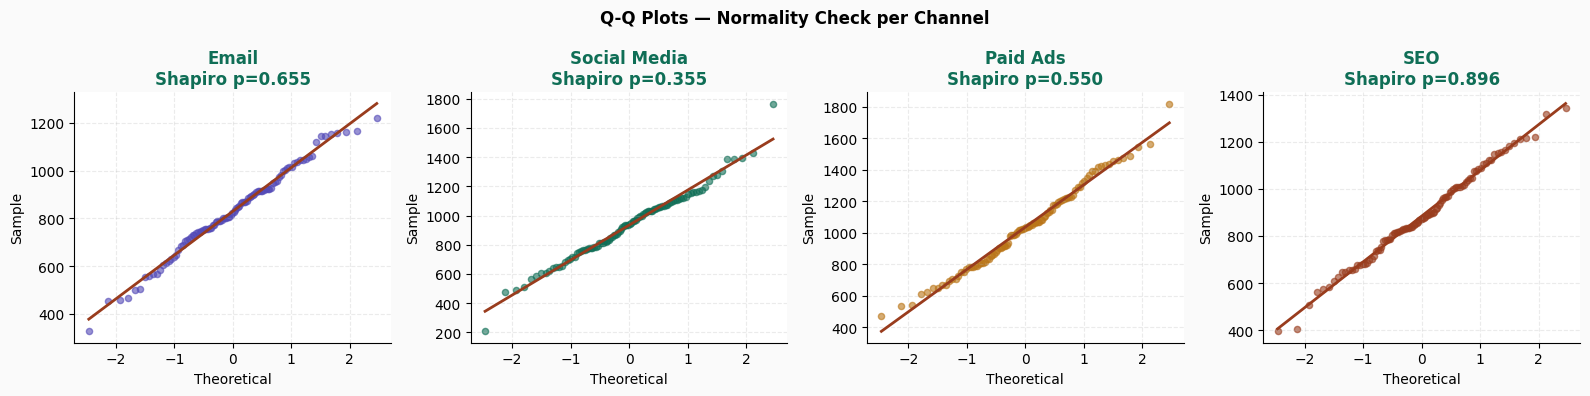

Q-Q plots saved


In [ ]:
# ── STEP 2: Normality Tests ─── ANOVA பயன்படுத்தலாமா இல்லையா என்பதை முடிவு செய்வது. ANOVA ஒரு Parametric Test.
# அதனால் முதலில் ஒரு முக்கிய நிபந்தனை: ✅ Data Normal Distribution follow செய்ய வேண்டும்.
print("STEP 2: Normality Check (Shapiro-Wilk, n=50 per group)")
print("="*60)
norm_df = normality_check(channels, n_sample=50) # Shapiro-Wilk Test
print(norm_df.to_string())
print()

# | p-value | Meaning       |
# | ------- | ------------- |
# | > 0.05  | Normal Data ✅ |
# | ≤ 0.05  | Not Normal ❌  |
# w-stat:
# | Channel  | W-stat |
# | -------- | ------ |
# | Email    | 0.9827 |
# | Social   | 0.9603 |
# | Paid Ads | 0.9772 |
# | SEO      | 0.9898 |
# RuleW value:1-க்கு அருகில் இருந்தால் Data Normal-ஆக இருக்கும். உங்கள் எல்லா W values-மும் 0.96–0.99 range-ல் இருக்கிறது.

all_normal = (norm_df['Normal?'] == 'Yes').all()
print(f"  All groups normal? {all_normal}")
print(f"  => Use {'parametric ANOVA' if all_normal else 'non-parametric Kruskal-Wallis'}")
print()

# Visual Q-Q Normality check
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Q-Q Plots — Normality Check per Channel', fontweight='bold')
for ax, (name, data), col in zip(axes, channels.items(), COLORS):
    sample = data[:100]
    (osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
    ax.scatter(osm, osr, color=col, alpha=0.6, s=20)
    ax.plot(osm, slope*np.array(osm)+intercept, color=CORAL, linewidth=2)
    p_sw = shapiro(sample)[1]
    ax.set_title(f'{name}\nShapiro p={p_sw:.3f}', fontweight='bold',
                 color=TEAL if p_sw>0.05 else CORAL)
    ax.set_xlabel('Theoretical'); ax.set_ylabel('Sample')
plt.tight_layout()
plt.savefig('p1_qqplots.png', dpi=120, bbox_inches='tight')
plt.show()
print("Q-Q plots saved")

# Paid Ads Customers: ₹1028.59 Average செலவழிக்கிறார்கள்.
# Email Customers: ₹841.85 Average செலவழிக்கிறார்கள்.
# இதைப் பார்த்தால் Difference இருப்பது போல தெரிகிறது. ஆனால் Statistical Significance இன்னும் தெரியாது. அதை ANOVA சொல்லும்.

# | Channel          | Shapiro p-value | p > 0.05? | Normal Distribution? | Q-Q Plot Observation                        | தமிழ் விளக்கம்                                                          |
# | ---------------- | --------------- | --------- | -------------------- | ------------------------------------------- | ----------------------------------------------------------------------- |
# | **Email**        | 0.655           | ✅ Yes     | ✅ Yes                | Points line-க்கு மிகவும் அருகில் உள்ளன      | Email Customers-ன் Order Values இயல்பான (Normal) Distribution-ல் உள்ளன. |
# | **Social Media** | 0.355           | ✅ Yes     | ✅ Yes                | பெரும்பாலான Points line-ஐ follow செய்கின்றன | Social Media Data-யும் Normal Distribution-ஐ பின்பற்றுகிறது.            |
# | **Paid Ads**     | 0.550           | ✅ Yes     | ✅ Yes                | Points நேர்கோட்டிற்கு அருகில் உள்ளன         | Paid Ads Customers Spending Pattern Normal ஆக உள்ளது.                   |
# | **SEO**          | 0.896           | ✅ Yes     | ✅ Yes                | Points line-க்கு மிகவும் நெருக்கமாக உள்ளன   | SEO Data மிகச் சிறந்த Normal Distribution-ஐ காட்டுகிறது.                |
# சில High Value Orders (Outliers) இருப்பது போல தெரிகிறது.ஆனால் Normality பாதிக்கவில்லை.


In [ ]:
# ── STEP 3: Variance Homogeneity ──அனைத்து Marketing Channels-க்கும் Variance (Spread) ஒரே மாதிரியா என்பதை கண்டுபிடிப்பது.
# ANOVA-வின் முக்கிய Assumptions-ல் ஒன்று: ✅ Equal Variance (Homogeneity of Variance)
print("STEP 3: Equal Variance Tests")
print("="*60)

# | p-value | Result              |
# | ------- | ------------------- |
# | > 0.05  | Equal Variances ✅   |
# | ≤ 0.05  | Unequal Variances ❌ |

# Levene (robust) and Bartlett (assumes normality)
lev_stat, lev_p = levene(*channels.values())  # Levene Test என்பது: "அனைத்து Groups-க்கும் Variance சமமா?" என்று பார்க்கிறது.
bar_stat, bar_p = bartlett(*channels.values()) # Bartlett Test-மும் Variance Check செய்யும். ஆனால்:⚠️ Data Normal ஆக இருக்கும்போது மிகவும் Sensitive.

print(f"  Levene test  : stat={lev_stat:.4f}  p={lev_p:.4f}  "
      f"=> {'Equal variances' if lev_p>0.05 else 'UNEQUAL variances'}") # Marketing Channels அனைத்தும் ஒரே அளவு Spread கொண்டிருக்கவில்லை.
print(f"  Bartlett test: stat={bar_stat:.4f}  p={bar_p:.4f}  "
      f"=> {'Equal variances' if bar_p>0.05 else 'UNEQUAL variances'}") 
print()
if lev_p > 0.05:
    print("  => Standard ANOVA is appropriate (variances are equal)")
else:
    print("  => Consider Welch ANOVA (does not assume equal variances)")

# Why Did This Happen? நீங்கள் Dataset Generate செய்தபோது:
# | Channel      | Std Dev | Spread
# | ------------ | ------- |
# | Email        | 200     | Medium
# | Social Media | 220     | அதிகம்
# | Paid Ads     | 250     | மிகவும் அதிகம்
# | SEO          | 180     | குறைவு
# அதனால் Statistical Test-லும் ❌ Variances Equal இல்லை என்று வந்துள்ளது.

STEP 3: Equal Variance Tests
  Levene test  : stat=7.5327  p=0.0001  => UNEQUAL variances
  Bartlett test: stat=25.0013  p=0.0000  => UNEQUAL variances

  => Consider Welch ANOVA (does not assume equal variances)


### Understanding ANOVA Logic

> 📌 **Tamil:** "ANOVA = Analysis of Variance. F-statistic = between-group variance / within-group variance.  

"பல Groups-ன் Average (Mean) ஒன்றா அல்லது வேறுபடுகிறதா?" என்பதை கண்டுபிடிக்கும் Statistical Test.

F-Statistic:
| Part           | Meaning                                             | தமிழ்                                  |
| -------------- | --------------------------------------------------- | -------------------------------------- |
| Between Groups | Group Means எவ்வளவு வேறுபடுகிறது?                   | குழுக்களுக்கிடையேயான வித்தியாசம்       |
| Within Groups  | ஒவ்வொரு Group-க்குள்ளும் இருக்கும் Random Variation | குழுவுக்குள் இருக்கும் இயல்பான மாற்றம் |


> F crassa இருந்தால் → groups really differ. F≈1 இருந்தால் → random noise."

| F Value           | Meaning                | தமிழ்                          |
| ----------------- | ---------------------- | ------------------------------ |
| F ≈ 1             | Between ≈ Within       | Groups Similar                 |
| F > 2             | Some Difference        | சிறிய வித்தியாசம்              |
| F > 5             | Strong Difference      | நல்ல வித்தியாசம்               |
| F மிகவும் பெரியது | Very Strong Difference | Groups உண்மையில் வேறுபடுகின்றன |

```
F = (Variance BETWEEN groups) / (Variance WITHIN groups)
  = (How different are group means?) / (How much random noise is there?)
```

F = Between Group Difference ÷ Within Group Noise

F சிறியது → Noise அதிகம், Difference குறைவு, 
F பெரியது → Difference அதிகம், Noise குறைவு.

**Null hypothesis H₀:** All channel means are equal (μ_email = μ_social = μ_paid = μ_seo)  
**Alternative H₁:** At least one channel mean is different


In [ ]:
# ── STEP 4: ONE-WAY ANOVA ─── Email, Social Media, Paid Ads, SEO ஆகிய 4 Marketing Channels-ன் Average Order Value (AOV) உண்மையில் வேறுபடுகிறதா?
print("STEP 4: One-Way ANOVA")
anova_result = run_anova(channels) # 4 Channels-ன் Data-வை ANOVA Test-க்கு அனுப்புகிறது.
print_anova(anova_result, name='Marketing Channel AOV — One-Way ANOVA') # output : f-statistic, p-value, eta-squared, decision
print() 

# Manual ANOVA table
grand_mean  = np.concatenate(list(channels.values())).mean() # எல்லா Channels-ன் Order Values-ஐ ஒன்றாக சேர்த்து Average எடுக்கிறது.
N_total     = sum(len(g) for g in channels.values()) # எல்லா Channels-லுள்ள Customers எண்ணிக்கையை கூட்டுகிறது.
k           = len(channels) # Number of groups (Channels)

ss_between = sum(len(g)*(g.mean()-grand_mean)**2 for g in channels.values())
ss_within  = sum(((g - g.mean())**2).sum() for g in channels.values())
ss_total   = ss_between + ss_within
ms_between = ss_between / (k-1)
ms_within  = ss_within  / (N_total-k)

print("  ANOVA Table:")
print(f"  {'Source':<15} {'SS':>12} {'df':>5} {'MS':>12} {'F':>8}")
print("  " + "-"*55)
print(f"  {'Between':<15} {ss_between:>12.2f} {k-1:>5} {ms_between:>12.2f} {ms_between/ms_within:>8.4f}")
print(f"  {'Within':<15} {ss_within:>12.2f} {N_total-k:>5} {ms_within:>12.2f}")
print(f"  {'Total':<15} {ss_total:>12.2f} {N_total-1:>5}")
print()
print(f"  eta-squared = SS_between/SS_total = {ss_between/ss_total:.4f}")
print(f"  Interpretation: {anova_result['eta2']*100:.1f}% of variance in AOV explained by channel")

# | Metric      | Value     | தமிழ் விளக்கம்                               |
# | ----------- | --------- | -------------------------------------------- |
# | F-statistic | 29.6357   | Groups-க்கிடையேயான Difference மிகவும் அதிகம் |
# | p-value     | 0.000000  | Difference Random Chance அல்ல                |
# | df_between  | 3         | 4 Groups → 4−1 = 3 , ANOVA-வில் ஒப்பிடப்படும் Group Count       |
# | df_within   | 796       | மொத்த 800 Customers − 4 Groups = 796  , Customer-level Variation அளவு        |
# | eta-squared | 0.1005    | Medium Effect                                |
# | Decision    | Reject H₀ | குறைந்தது ஒரு Channel வேறுபடுகிறது           |

# | Eta²      | Meaning |
# | --------- | ------- |
# | <0.06     | Small   |
# | 0.06-0.14 | Medium  |
# | >0.14     | Large   |

# | Question                           | Answer                                                           |
# | ---------------------------------- | ---------------------------------------------------------------- |
# | Channels Same AOV தருகிறதா?        | ❌ இல்லை                                                          |
# | Statistical Difference இருக்கிறதா? | ✅ ஆம்                                                            |
# | Difference Significant ஆ?          | ✅ ஆம் (p<0.001)                                                  |
# | Marketing Channel முக்கியமா?       | ✅ ஆம்                                                            |
# | எவ்வளவு முக்கியம்?                 | AOV Variation-ல் 10% Explain செய்கிறது                           |
# | Next Step?                         | Tukey HSD மூலம் எந்த Channel வேறுபடுகிறது என்று பார்க்க வேண்டும் |

# Marketing Channel முக்கிய காரணமா?
# ✅ ஆம், AOV Variation-ல் ~10% Explain செய்கிறது

STEP 4: One-Way ANOVA
  Marketing Channel AOV — One-Way ANOVA
  F-statistic    : 29.6357
  df (between)   : 3
  df (within)    : 796
  p-value        : 0.000000
  eta-squared    : 0.1005  (medium effect)
  Decision       : REJECT H0 — at least one group differs

  ANOVA Table:
  Source                    SS    df           MS        F
  -------------------------------------------------------
  Between           3939900.03     3   1313300.01  29.6357
  Within           35274575.32   796     44314.79
  Total            39214475.36   799

  eta-squared = SS_between/SS_total = 0.1005
  Interpretation: 10.0% of variance in AOV explained by channel


In [ ]:
# ── STEP 5: TUKEY HSD POST-HOC ──────ANOVA நமக்கு சொல்வது: "குறைந்தது ஒரு Channel வேறுபடுகிறது" 
# ஆனால் ANOVA சொல்லாதது: "எந்த Channel எந்த Channel-ஐ விட வேறுபடுகிறது?" அதற்காகத்தான் Tukey HSD Post-Hoc Test.
print("STEP 5: Tukey HSD Post-Hoc Test (which pairs differ?)") 
print("="*60)
print()

all_vals = np.concatenate(list(channels.values())) # அனைத்து Values-ஐ ஒன்றாக சேர்க்கிறது
all_grps = sum([[name]*len(data) for name,data in channels.items()], []) # ஒவ்வொரு Value எந்த Channel-க்கு சொந்தமானது என்று Tukey தெரிந்து கொள்ள வேண்டும்.

tukey = pairwise_tukeyhsd(all_vals, all_grps, alpha=0.05) # அனைத்து Pair-களையும் Compare செய்கிறது. (alpha=0.05 → 95% confidence level)
print(tukey)
print()
# | Pair               |
# | ------------------ |
# | Email vs Social    |
# | Email vs Paid Ads  |
# | Email vs SEO       |
# | Social vs Paid Ads |
# | Social vs SEO      |
# | Paid Ads vs SEO    |


# Effect sizes for each pair
print("  Effect sizes (Cohen's d) for significant pairs:")
ch_names = list(channels.keys())
for i in range(len(ch_names)):
    for j in range(i+1, len(ch_names)):
        n1, n2 = ch_names[i], ch_names[j]
        d = cohens_d(channels[n1], channels[n2]) # Difference இருக்கிறது என்று Tukey சொல்கிறது. ஆனால்: "Difference எவ்வளவு பெரியது?" என்பதை Cohen's d சொல்கிறது.
# | d Value   | Meaning |
# | --------- | ------- |
# | <0.20     | Small   |
# | 0.20-0.50 | Medium  |
# | >0.50     | Large   | Paid Ads Customers Email Customers-ஐ விட குறிப்பிடத்தக்க அளவு அதிகமாக செலவழிக்கிறார்கள்.

        print(f"    {n1} vs {n2}: d={d:.3f}  "
              f"({'small' if d<0.2 else 'medium' if d<0.5 else 'large'})")

# | Column   | Meaning                | தமிழ் விளக்கம்                                          |
# | -------- | ---------------------- | ------------------------------------------------------- |
# | group1   | First Group            | முதல் Marketing Channel                                 |
# | group2   | Second Group           | இரண்டாவது Marketing Channel                             |
# | meandiff | Mean Difference        | இரண்டு Channels-ன் Average Order Value வித்தியாசம்      |
# | p-adj    | Adjusted p-value       | Multiple Comparisons-க்கு சரிசெய்யப்பட்ட p-value        |
# | lower    | Lower Confidence Limit | Mean Difference-ன் குறைந்த எல்லை                        |
# | upper    | Upper Confidence Limit | Mean Difference-ன் அதிக எல்லை                           |
# | reject   | Reject H₀?             | True = Significant Difference, False = Difference இல்லை |

# | Comparison                   | Mean Diff (₹) |  p-adj | Significant? | தமிழ் விளக்கம்                                                            | Business Meaning                              |
# | ---------------------------- | ------------: | -----: | ------------ | ------------------------------------------------------------------------- | --------------------------------------------- |
# | **Email vs Paid Ads**        |        186.74 | 0.0000 | ✅ Yes        | Paid Ads Customers Email-ஐ விட சராசரியாக ₹186.74 அதிகம் செலவழிக்கிறார்கள் | Paid Ads சிறந்த Channel                       |
# | **Email vs SEO**             |         39.77 | 0.2335 | ❌ No         | Difference சிறியது, Statistical-ஆக முக்கியமில்லை                          | Email மற்றும் SEO கிட்டத்தட்ட ஒரே Performance |
# | **Email vs Social Media**    |         97.05 | 0.0000 | ✅ Yes        | Social Media Customers Email-ஐ விட ₹97 அதிகம் செலவழிக்கிறார்கள்           | Social > Email                                |
# | **Paid Ads vs SEO**          |       -146.97 | 0.0000 | ✅ Yes        | Paid Ads Customers SEO-வை விட ₹147 அதிகம் செலவழிக்கிறார்கள்               | Paid Ads > SEO                                |
# | **Paid Ads vs Social Media** |        -89.70 | 0.0001 | ✅ Yes        | Paid Ads Customers Social Media-வை விட ₹90 அதிகம் செலவழிக்கிறார்கள்       | Paid Ads > Social                             |
# | **SEO vs Social Media**      |         57.28 | 0.0336 | ✅ Yes        | Social Media Customers SEO-வை விட ₹57 அதிகம் செலவழிக்கிறார்கள்            | Social > SEO                                  |


# | Comparison               | Cohen's d | Effect Size               | தமிழ் விளக்கம்                                      |
# | ------------------------ | --------- | ------------------------- | --------------------------------------------------- |
# | Email vs Social Media    | 0.481     | Medium                    | Social Media Email-ஐ விட மிதமான அளவு சிறந்தது       |
# | Email vs Paid Ads        | 0.853     | Large                     | Paid Ads Email-ஐ விட மிகவும் சிறந்தது               |
# | Email vs SEO             | 0.216     | Medium (சிறியது-மிதமானது) | Difference இருந்தாலும் Significant இல்லை            |
# | Social Media vs Paid Ads | 0.385     | Medium                    | Paid Ads சிறிதளவு மேலோங்குகிறது                     |
# | Social Media vs SEO      | 0.286     | Medium                    | Social Media SEO-வை விட சிறந்தது                    |
# | Paid Ads vs SEO          | 0.674     | Large                     | Paid Ads SEO-வை விட குறிப்பிடத்தக்க அளவில் சிறந்தது |


STEP 5: Tukey HSD Post-Hoc Test (which pairs differ?)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
 group1     group2     meandiff p-adj    lower    upper   reject
----------------------------------------------------------------
   Email     Paid Ads  186.7404    0.0  132.5451 240.9357   True
   Email          SEO   39.7682 0.2335  -14.4271  93.9635  False
   Email Social Media   97.0452    0.0   42.8499 151.2405   True
Paid Ads          SEO -146.9722    0.0 -201.1675  -92.777   True
Paid Ads Social Media  -89.6952 0.0001 -143.8905 -35.4999   True
     SEO Social Media    57.277 0.0336    3.0817 111.4723   True
----------------------------------------------------------------

  Effect sizes (Cohen's d) for significant pairs:
    Email vs Social Media: d=0.481  (medium)
    Email vs Paid Ads: d=0.853  (large)
    Email vs SEO: d=0.216  (medium)
    Social Media vs Paid Ads: d=0.385  (medium)
    Social Media vs SEO: d=0.286  (medium)
    Paid Ads vs SEO: d=0.674  (l

In [ ]:
# ── STEP 6: BUSINESS DECISION ───ANOVA மற்றும் Tukey Test மூலம்:✅ எந்த Channel சிறந்தது? ✅ எந்த Channel மோசமானது?
# என்று கண்டுபிடித்தோம். இப்போது: Marketing Budget-ஐ எப்படி மாற்றினால் அதிக Revenue கிடைக்கும்? என்பதை கணக்கிடுகிறோம்.
print("STEP 6: Budget Reallocation Recommendation")
print("="*60)
print()

current_budget = {'Email':800000, 'Social Media':1500000,
                  'Paid Ads':2000000, 'SEO':700000}

# Return On Ad Spend(ROAS)= Revenue​ / Advertising Budget

# | ROAS | Meaning    |
# | ---- | ---------- |
# | <1x  | Loss       |
# | 1x   | Break Even |
# | 2x   | Good       |
# | 3x+  | Excellent  | Budget- ₹100 ; Revenue - ₹300 => ROAS = 300/100 =3x ; Meaning: ₹1 செலவழித்தால் ₹3 Revenue கிடைக்கிறது.

channel_roas = {}
for ch, data in channels.items():
    aov  = data.mean()
    n_c  = len(data)
    rev  = aov * n_c
    roas = rev / current_budget[ch]
    channel_roas[ch] = roas
    print(f"  {ch:<15}: AOV=₹{aov:,.0f}  Revenue=₹{rev:,.0f}  "
          f"Budget=₹{current_budget[ch]:,.0f}  ROAS={roas:.2f}x")

total_budget = sum(current_budget.values())
print(f"\n  Total current budget: ₹{total_budget:,.0f}")
best_ch = max(channel_roas, key=channel_roas.get)
worst_ch = min(channel_roas, key=channel_roas.get)
print(f"\n  Best ROAS  : {best_ch} ({channel_roas[best_ch]:.2f}x)")
print(f"  Worst ROAS : {worst_ch} ({channel_roas[worst_ch]:.2f}x)")
print()
print(f"  RECOMMENDATION:")
print(f"  => Increase {best_ch} budget by 30% (₹{0.3*current_budget[best_ch]:,.0f})")
print(f"  => Reduce {worst_ch} budget by 20% (₹{0.2*current_budget[worst_ch]:,.0f})")
print(f"  => Estimated revenue uplift: ₹{(channel_roas[best_ch]-channel_roas[worst_ch])*total_budget*0.1:,.0f}")

# | Channel      | AOV (சராசரி Order Value) | Revenue (வருமானம்) | Budget (செலவு) |  ROAS | தமிழ் விளக்கம்                              |
# | ------------ | -----------------------: | -----------------: | -------------: | ----: | ------------------------------------------- |
# | Email        |                     ₹842 |           ₹168,369 |       ₹800,000 | 0.21x | ₹1 செலவு செய்தால் ₹0.21 Revenue கிடைக்கிறது |
# | Social Media |                     ₹939 |           ₹187,778 |     ₹1,500,000 | 0.13x | Revenue நல்லது, ஆனால் Budget அதிகம்         |
# | Paid Ads     |                   ₹1,029 |           ₹205,717 |     ₹2,000,000 | 0.10x | AOV அதிகம், ஆனால் செலவு மிகவும் அதிகம்      |
# | SEO          |                     ₹882 |           ₹176,323 |       ₹700,000 | 0.25x | குறைந்த Budget-ல் அதிக Return தருகிறது      |

# | Rank | Channel      | ROAS  | தமிழ் விளக்கம்            |
# | ---- | ------------ | ----- | ------------------------- |
# | 🥇 1 | SEO          | 0.25x | மிகவும் Efficient Channel |
# | 🥈 2 | Email        | 0.21x | நல்ல Return               |
# | 🥉 3 | Social Media | 0.13x | சராசரி Performance        |
# | 4    | Paid Ads     | 0.10x | குறைந்த Return            |

# | Category   | Channel  | ROAS  | தமிழ் விளக்கம்               |
# | ---------- | -------- | ----- | ---------------------------- |
# | Best ROAS  | SEO      | 0.25x | குறைந்த செலவில் அதிக Revenue |
# | Worst ROAS | Paid Ads | 0.10x | அதிக செலவில் குறைந்த Revenue |

# | Action   | Channel  | Current Budget | Change |   Amount | New Budget |
# | -------- | -------- | -------------: | ------ | -------: | ---------: |
# | Increase | SEO      |       ₹700,000 | +30%   | ₹210,000 |   ₹910,000 |
# | Reduce   | Paid Ads |     ₹2,000,000 | -20%   | ₹400,000 | ₹1,600,000 |

# | Metric                   |      Value | தமிழ் விளக்கம்                                   |
# | ------------------------ | ---------: | ------------------------------------------------ |
# | Total Current Budget     | ₹5,000,000 | மொத்த Marketing Budget                           |
# | Estimated Revenue Uplift |    ₹74,516 | Budget மாற்றினால் கிடைக்கக்கூடிய கூடுதல் Revenue |

# | Step            | Calculation        | Result    |
# | --------------- | ------------------ | --------- |
# | Best ROAS       | SEO                | 0.2519    |
# | Worst ROAS      | Paid Ads           | 0.1029    |
# | ROAS Difference | 0.2519 − 0.1029    | 0.1490    |
# | Budget Shift    | ₹50,00,000 × 10%   | ₹5,00,000 | மொத்த Budget-ல் 10% (₹5 லட்சம்) Worst Channel-லிருந்து Best Channel-க்கு மாற்றுகிறோம் என்று Assume செய்கிறது.
# | Revenue Uplift  | 0.1490 × ₹5,00,000 | ₹74,516   |


STEP 6: Budget Reallocation Recommendation

  Email          : AOV=₹842  Revenue=₹168,369  Budget=₹800,000  ROAS=0.21x
  Social Media   : AOV=₹939  Revenue=₹187,778  Budget=₹1,500,000  ROAS=0.13x
  Paid Ads       : AOV=₹1,029  Revenue=₹205,717  Budget=₹2,000,000  ROAS=0.10x
  SEO            : AOV=₹882  Revenue=₹176,323  Budget=₹700,000  ROAS=0.25x

  Total current budget: ₹5,000,000

  Best ROAS  : SEO (0.25x)
  Worst ROAS : Paid Ads (0.10x)

  RECOMMENDATION:
  => Increase SEO budget by 30% (₹210,000)
  => Reduce Paid Ads budget by 20% (₹400,000)
  => Estimated revenue uplift: ₹74,516


📦 Chart 1: Order Value Distribution by Channel (Box Plot)
Channel	என்ன தெரிகிறது?	தமிழ் விளக்கம்
Email	Median குறைவு	Email மூலம் வரும் Customers குறைவாக செலவழிக்கிறார்கள்
Social Media	Email-ஐ விட உயர்வு	Social மூலம் வந்தவர்கள் அதிகம் வாங்குகிறார்கள்
Paid Ads	Highest Median	Paid Ads Customers அதிக Order Value தருகிறார்கள்
SEO	Social-க்கு அருகில்	SEO நல்ல Performance காட்டுகிறது
🎯 Story
சிவப்பு கோடு = Grand Mean ₹923
Paid Ads Box முழுவதும் Grand Mean-க்கு மேல் உள்ளது.
Email Box பெரும்பாலும் Grand Mean-க்கு கீழே உள்ளது.
Conclusion
Paid Ads → Premium Customers
Email → Low Value Customers
📊 Chart 2: Mean AOV + 95% Confidence Interval
Channel	Mean AOV
Email	₹842
Social Media	₹939
Paid Ads	₹1029
SEO	₹882
🎯 Story
Paid Ads மிக உயர்ந்த Average Order Value.
Email மிகக் குறைவு.
Error Bars (95% CI) சிறியதாக உள்ளதால் Mean estimates நம்பகமானவை.
Conclusion
Paid Ads Customers சராசரியாக அதிக பணம் செலவழிக்கிறார்கள்.
📈 Chart 3: F Distribution (ANOVA)
Metric	Value
Critical Value	2.62
Actual F	29.64
🎯 Story
சிவப்பு கோடு = Critical Value
நீல கோடு = Actual F Statistic

ANOVA சொல்கிறது:

29.64 >> 2.62

அதாவது:

இந்த Difference Random Chance அல்ல.

Conclusion

✅ Channels அனைத்தும் ஒரே மாதிரி இல்லை.

🔥 Chart 4: Tukey HSD p-value Matrix
Color Meaning
Color	Meaning
Green	Significant Difference
Red	Not Significant
Chart Observation
Pair	p-value	Result
Email vs Social	0.000	Significant
Email vs Paid Ads	0.000	Significant
Email vs SEO	0.234	Not Significant
Social vs SEO	0.034	Significant
Paid Ads vs SEO	0.000	Significant
🎯 Story

ஒரே சிவப்பு Box:

Email ↔ SEO

மட்டுமே.

Conclusion
Email மற்றும் SEO மட்டும் ஒரே மாதிரி.
மற்ற எல்லா Pairs-லும் Difference உள்ளது.
💪 Chart 5: Effect Size Matrix (Cohen's d)
Color Meaning
Value	Meaning
0.2	Small
0.5	Medium
0.8	Large
Biggest Effects
Comparison	d
Email vs Paid Ads	0.85
Paid Ads vs SEO	0.67
🎯 Story
Statistics மட்டும் இல்லை.
Practical Difference-மும் பார்க்கிறோம்.
Conclusion
Paid Ads மற்றும் Email இடையே பெரிய Business Difference உள்ளது.
💰 Chart 6: ROAS by Channel
Channel	ROAS
Email	0.21x
Social Media	0.13x
Paid Ads	0.10x
SEO	0.25x
🎯 Story

இங்கே ஒரு Surprise!

Paid Ads AOV Highest.

ஆனால்:

Paid Ads ROAS Lowest.

ஏன்?

Budget மிகவும் அதிகம்.

SEO:

Budget குறைவு
Return அதிகம்
Conclusion
Efficiency Winner = SEO
🍩 Chart 7: Budget Current vs Proposed
Outer Ring

Current Budget

Inner Ring

Recommended Budget

What Changed?
Channel	Change
SEO	+30%
Paid Ads	-20%
Email	No Change
Social	No Change
🎯 Story
Current Budget
Paid Ads = அதிகம்
SEO = குறைவு
Proposed Budget
SEO = அதிகரிப்பு
📦 Chart 1: Order Value Distribution by Channel (Box Plot)
Channel	என்ன தெரிகிறது?	தமிழ் விளக்கம்
Email	Median குறைவு	Email மூலம் வரும் Customers குறைவாக செலவழிக்கிறார்கள்
Social Media	Email-ஐ விட உயர்வு	Social மூலம் வந்தவர்கள் அதிகம் வாங்குகிறார்கள்
Paid Ads	Highest Median	Paid Ads Customers அதிக Order Value தருகிறார்கள்
SEO	Social-க்கு அருகில்	SEO நல்ல Performance காட்டுகிறது
🎯 Story
சிவப்பு கோடு = Grand Mean ₹923
Paid Ads Box முழுவதும் Grand Mean-க்கு மேல் உள்ளது.
Email Box பெரும்பாலும் Grand Mean-க்கு கீழே உள்ளது.
Conclusion
Paid Ads → Premium Customers
Email → Low Value Customers
📊 Chart 2: Mean AOV + 95% Confidence Interval
Channel	Mean AOV
Email	₹842
Social Media	₹939
Paid Ads	₹1029
SEO	₹882
🎯 Story
Paid Ads மிக உயர்ந்த Average Order Value.
Email மிகக் குறைவு.
Error Bars (95% CI) சிறியதாக உள்ளதால் Mean estimates நம்பகமானவை.
Conclusion
Paid Ads Customers சராசரியாக அதிக பணம் செலவழிக்கிறார்கள்.
📈 Chart 3: F Distribution (ANOVA)
Metric	Value
Critical Value	2.62
Actual F	29.64
🎯 Story
சிவப்பு கோடு = Critical Value
நீல கோடு = Actual F Statistic

ANOVA சொல்கிறது:

29.64 >> 2.62

அதாவது:

இந்த Difference Random Chance அல்ல.

Conclusion

✅ Channels அனைத்தும் ஒரே மாதிரி இல்லை.

🔥 Chart 4: Tukey HSD p-value Matrix
Color Meaning
Color	Meaning
Green	Significant Difference
Red	Not Significant
Chart Observation
Pair	p-value	Result
Email vs Social	0.000	Significant
Email vs Paid Ads	0.000	Significant
Email vs SEO	0.234	Not Significant
Social vs SEO	0.034	Significant
Paid Ads vs SEO	0.000	Significant
🎯 Story

ஒரே சிவப்பு Box:

Email ↔ SEO

மட்டுமே.

Conclusion
Email மற்றும் SEO மட்டும் ஒரே மாதிரி.
மற்ற எல்லா Pairs-லும் Difference உள்ளது.
💪 Chart 5: Effect Size Matrix (Cohen's d)
Color Meaning
Value	Meaning
0.2	Small
0.5	Medium
0.8	Large
Biggest Effects
Comparison	d
Email vs Paid Ads	0.85
Paid Ads vs SEO	0.67
🎯 Story
Statistics மட்டும் இல்லை.
Practical Difference-மும் பார்க்கிறோம்.
Conclusion
Paid Ads மற்றும் Email இடையே பெரிய Business Difference உள்ளது.
💰 Chart 6: ROAS by Channel
Channel	ROAS
Email	0.21x
Social Media	0.13x
Paid Ads	0.10x
SEO	0.25x
🎯 Story

இங்கே ஒரு Surprise!

Paid Ads AOV Highest.

ஆனால்:

Paid Ads ROAS Lowest.

ஏன்?

Budget மிகவும் அதிகம்.

SEO:

Budget குறைவு
Return அதிகம்
Conclusion
Efficiency Winner = SEO
🍩 Chart 7: Budget Current vs Proposed
Outer Ring

Current Budget

Inner Ring

Recommended Budget

What Changed?
Channel	Change
SEO	+30%
Paid Ads	-20%
Email	No Change
Social	No Change
🎯 Story
Current Budget
Paid Ads = அதிகம்
SEO = குறைவு
Proposed Budget
SEO = அதிகரிப்பு

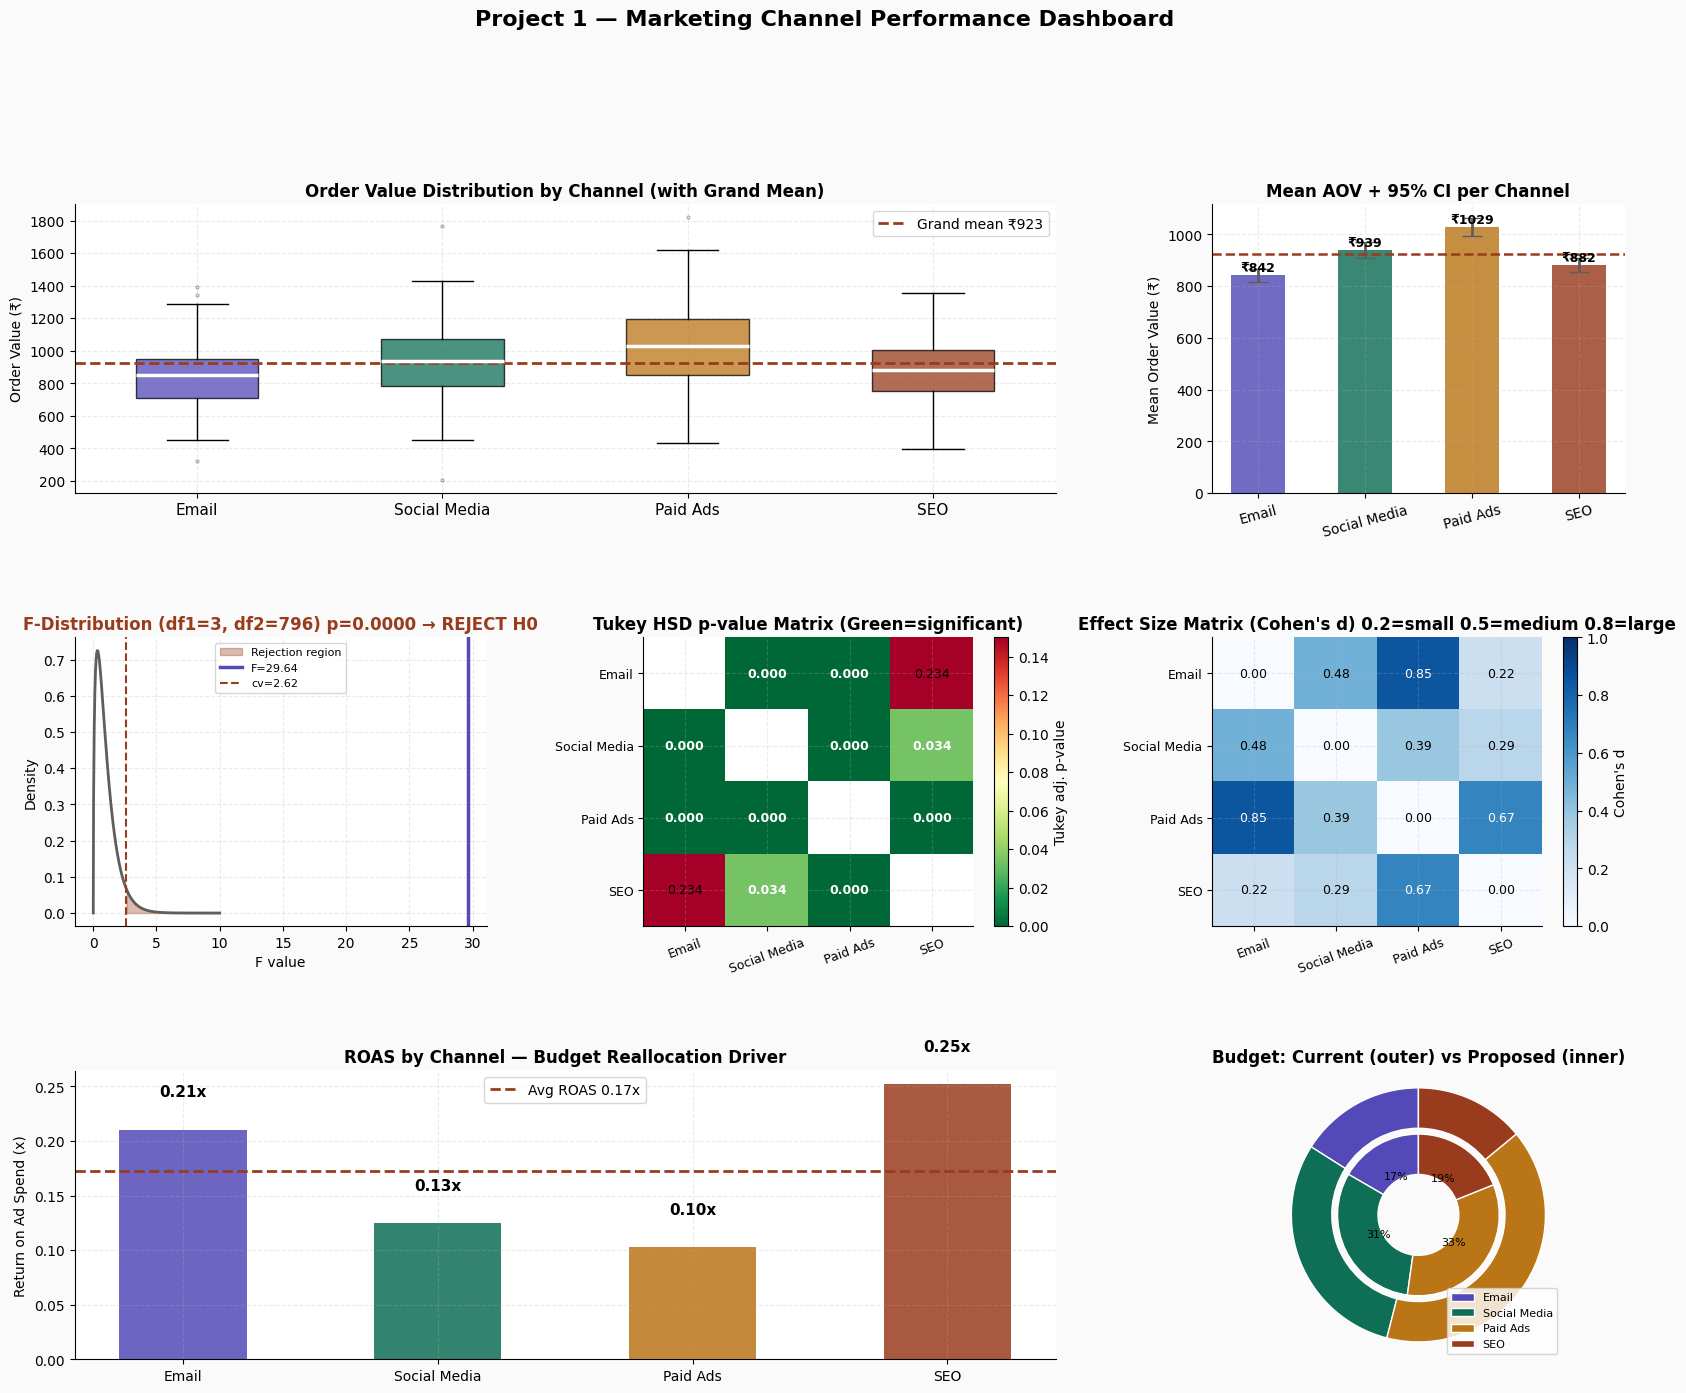

Dashboard saved: p1_marketing_dashboard.png


In [ ]:
# ── FULL DASHBOARD ────────────────────────────────────────────
fig = plt.figure(figsize=(20, 15))
fig.suptitle('Project 1 — Marketing Channel Performance Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# P1: Box plot
ax1 = fig.add_subplot(gs[0, :2])
data_for_box = [channels[ch] for ch in channels]
bp = ax1.boxplot(data_for_box, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2.5),
                 flierprops=dict(marker='.', alpha=0.3, markersize=4),
                 widths=0.5)
for patch, col in zip(bp['boxes'], COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax1.set_xticklabels(list(channels.keys()), fontsize=11)
ax1.axhline(grand_mean, color=CORAL, linewidth=2, linestyle='--',
            label=f'Grand mean ₹{grand_mean:.0f}')
ax1.set_title('Order Value Distribution by Channel (with Grand Mean)',
              fontweight='bold')
ax1.set_ylabel('Order Value (₹)'); ax1.legend(fontsize=10)

# P2: Mean + CI bars
ax2 = fig.add_subplot(gs[0, 2])
means = [channels[ch].mean() for ch in channels]
sems  = [stats.sem(channels[ch]) for ch in channels]
t_cv  = stats.t.ppf(0.975, df=n-1)
bars  = ax2.bar(list(channels.keys()), means, color=COLORS[:4], alpha=0.82, width=0.5)
ax2.errorbar(range(len(channels)), means,
             yerr=[t_cv*s for s in sems],
             fmt='none', color=DGRAY, capsize=7, linewidth=2)
ax2.axhline(grand_mean, color=CORAL, linewidth=1.8, linestyle='--')
for bar, m in zip(bars, means):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
             f'₹{m:.0f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Mean AOV + 95% CI per Channel', fontweight='bold')
ax2.set_ylabel('Mean Order Value (₹)')
ax2.tick_params(axis='x', rotation=15)

# P3: ANOVA F-distribution
ax3 = fig.add_subplot(gs[1, 0])
x_f  = np.linspace(0, 10, 400)
df1, df2 = anova_result['df_between'], anova_result['df_within']
y_f  = stats.f.pdf(x_f, df1, df2)
ax3.plot(x_f, y_f, color=DGRAY, linewidth=2)
cv_f = stats.f.ppf(0.95, df1, df2)
xfill = x_f[x_f >= cv_f]
ax3.fill_between(xfill, 0, stats.f.pdf(xfill,df1,df2),
                 color=CORAL, alpha=0.35, label=f'Rejection region')
ax3.axvline(anova_result['F'], color=PURPLE, linewidth=2.5,
            label=f"F={anova_result['F']:.2f}")
ax3.axvline(cv_f, color=CORAL, linewidth=1.5, linestyle='--',
            label=f'cv={cv_f:.2f}')
ax3.set_title(f"F-Distribution (df1={df1}, df2={df2}) p={anova_result['p']:.4f} → REJECT H0",
              fontweight='bold', color=CORAL)
ax3.set_xlabel('F value'); ax3.set_ylabel('Density'); ax3.legend(fontsize=8)

# P4: Tukey HSD matrix
ax4 = fig.add_subplot(gs[1, 1])
ch_list = list(channels.keys())
p_matrix = pd.DataFrame(np.ones((4,4)), index=ch_list, columns=ch_list)
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                         columns=tukey._results_table.data[0])
for _, row in tukey_df.iterrows():
    g1, g2 = row['group1'], row['group2']
    p_val  = float(row['p-adj'])
    p_matrix.loc[g1,g2] = p_val
    p_matrix.loc[g2,g1] = p_val
arr = p_matrix.values.copy().astype(float)
np.fill_diagonal(arr, np.nan)
im = ax4.imshow(arr, cmap='RdYlGn_r', vmin=0, vmax=0.15, aspect='auto')
ax4.set_xticks(range(4)); ax4.set_yticks(range(4))
ax4.set_xticklabels(ch_list, rotation=20, fontsize=9)
ax4.set_yticklabels(ch_list, fontsize=9)
for i in range(4):
    for j in range(4):
        if i != j:
            v = arr[i,j]
            ax4.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=9,
                     color='white' if v < 0.05 else 'black',
                     fontweight='bold' if v < 0.05 else 'normal')
plt.colorbar(im, ax=ax4, label='Tukey adj. p-value')
ax4.set_title('Tukey HSD p-value Matrix (Green=significant)', fontweight='bold')

# P5: Effect sizes heatmap
ax5 = fig.add_subplot(gs[1, 2])
d_matrix = np.zeros((4,4))
for i, n1 in enumerate(ch_list):
    for j, n2 in enumerate(ch_list):
        if i != j:
            d_matrix[i,j] = cohens_d(channels[n1], channels[n2])
im5 = ax5.imshow(d_matrix, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax5.set_xticks(range(4)); ax5.set_yticks(range(4))
ax5.set_xticklabels(ch_list, rotation=20, fontsize=9)
ax5.set_yticklabels(ch_list, fontsize=9)
for i in range(4):
    for j in range(4):
        ax5.text(j, i, f'{d_matrix[i,j]:.2f}',
                 ha='center', va='center', fontsize=9,
                 color='white' if d_matrix[i,j]>0.5 else 'black')
plt.colorbar(im5, ax=ax5, label="Cohen's d")
ax5.set_title(f"Effect Size Matrix (Cohen's d) 0.2=small 0.5=medium 0.8=large",
              fontweight='bold')

# P6: ROAS comparison
ax6 = fig.add_subplot(gs[2, :2])
roas_vals = [channel_roas[ch] for ch in channels]
bars6 = ax6.bar(list(channels.keys()), roas_vals,
                color=COLORS[:4], alpha=0.85, width=0.5)
for bar, v in zip(bars6, roas_vals):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
             f'{v:.2f}x', ha='center', fontsize=11, fontweight='bold')
ax6.axhline(np.mean(roas_vals), color=CORAL, linewidth=2,
            linestyle='--', label=f'Avg ROAS {np.mean(roas_vals):.2f}x')
ax6.set_title('ROAS by Channel — Budget Reallocation Driver', fontweight='bold')
ax6.set_ylabel('Return on Ad Spend (x)'); ax6.legend(fontsize=10)

# P7: Budget pie current vs proposed
ax7 = fig.add_subplot(gs[2, 2])
proposed = {ch: int(current_budget[ch] * (1.3 if ch==best_ch else
                                           0.8 if ch==worst_ch else 1.0))
            for ch in channels}
outer = ax7.pie(current_budget.values(), radius=1.1,
                labels=None, colors=COLORS[:4],
                startangle=90, wedgeprops=dict(width=0.35, edgecolor='white'))
inner = ax7.pie(proposed.values(), radius=0.7,
                labels=None, colors=COLORS[:4],
                startangle=90, wedgeprops=dict(width=0.35, edgecolor='white'),
                autopct='%1.0f%%', pctdistance=0.55,
                textprops=dict(fontsize=8))
ax7.set_title('Budget: Current (outer) vs Proposed (inner)',
              fontweight='bold')
ax7.legend(list(channels.keys()), loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('p1_marketing_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print("Dashboard saved: p1_marketing_dashboard.png")

# | Step | Story                                                              |
# | ---- | ------------------------------------------------------------------ |
# | 1️⃣  | Email, Social Media, Paid Ads, SEO ஆகிய Channels-ஐ ஒப்பிட்டோம்.    |
# | 2️⃣  | Paid Ads Customers அதிக Order Value கொடுக்கிறார்கள் என்று கண்டோம். |
# | 3️⃣  | ANOVA மூலம் இந்த Difference உண்மையானது என்று நிரூபித்தோம்.         |
# | 4️⃣  | Tukey Test மூலம் எந்த Channels வேறுபடுகின்றன என்று கண்டோம்.        |
# | 5️⃣  | Effect Size மூலம் Paid Ads-ன் தாக்கம் பெரியது என்று கண்டோம்.       |
# | 6️⃣  | ஆனால் Revenue மட்டும் போதாது; ROAS-ஐ பார்த்தோம்.                   |
# | 7️⃣  | SEO குறைந்த செலவில் அதிக Return கொடுக்கிறது என்று தெரிந்தது.       |
# | 8️⃣  | Paid Ads-ல் இருந்து சில Budget-ஐ SEO-க்கு மாற்ற பரிந்துரைத்தோம்.   |
# | 9️⃣  | இதனால் சுமார் ₹74,516 கூடுதல் Revenue கிடைக்கலாம்.                 |


# | Chart  | Chart Name                          | இந்த Chart என்ன காட்டுகிறது?          | கதை (Story)                                                                                                                    | Business Decision                                         |
# | ------ | ----------------------------------- | ------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------ | --------------------------------------------------------- |
# | **P1** | Order Value Distribution (Box Plot) | ஒவ்வொரு Channel-ன் Order Value Spread | **Paid Ads**-ல் Customers அதிகமாக செலவழிக்கிறார்கள். **Email**-ல் குறைவாக செலவழிக்கிறார்கள். SEO மற்றும் Social நடுவில் உள்ளன. | Paid Ads High Value Customers-ஐ கொண்டு வருகிறது.          |
# | **P2** | Mean AOV + 95% CI                   | Channel-ன் Average Order Value        | Paid Ads-ன் Average Order Value மற்ற Channels-ஐ விட தெளிவாக உயர்ந்துள்ளது. Email மிகவும் குறைவு.                               | Paid Ads Quality Customers-ஐ தருகிறது.                    |
# | **P3** | ANOVA F Distribution                | Difference உண்மையா அல்லது Chance ஆ?   | F=29.64 என்பது Critical Value-ஐ விட மிகப்பெரியது. இது "இந்த Difference உண்மையானது" என்று சொல்கிறது.                            | Channels அனைத்தும் ஒரே மாதிரி இல்லை.                      |
# | **P4** | Tukey HSD p-value Matrix            | எந்த Channel Pair வேறுபடுகிறது?       | பெரும்பாலான Pair-களில் Significant Difference உள்ளது. Email vs SEO மட்டும் ஒரே மாதிரி.                                         | Paid Ads, Social Media மற்ற Channels-ஐ விட வேறுபடுகின்றன. |
# | **P5** | Cohen's d Effect Size Matrix        | Difference எவ்வளவு பெரியது?           | Paid Ads vs Email மற்றும் Paid Ads vs SEO இடையே பெரிய Effect உள்ளது.                                                           | Paid Ads-ன் தாக்கம் நடைமுறையிலும் முக்கியமானது.           |
# | **P6** | ROAS by Channel                     | ₹1 செலவுக்கு எவ்வளவு Return?          | SEO அதிக Return தருகிறது. Paid Ads குறைந்த Return தருகிறது.                                                                    | Budget-ஐ SEO-க்கு மாற்றலாம்.                              |
# | **P7** | Current vs Proposed Budget          | Budget மாற்றினால் என்ன ஆகும்?         | Paid Ads Budget குறைகிறது. SEO Budget அதிகரிக்கிறது.                                                                           | Revenue அதிகரிக்க Budget Reallocation.                    |


---
---
# ⭐ Project 2 — Product Ratings: Non-Parametric Tests
## Kruskal-Wallis + Mann-Whitney U

---

### Business Problem
An e-commerce platform collects 1–5 star ratings across 4 product categories.  
Are ratings significantly different across categories?

> 📌 **Tamil:** "Rating data ordinal data — normal distribution assume பண்ண முடியாது.  
> Non-parametric tests normal assumption தேவை இல்லாமல் work பண்ணும்.  
> Kruskal-Wallis = non-parametric ANOVA. Mann-Whitney = non-parametric t-test."

### When to use Non-Parametric Tests?
- Data is **ordinal** (ratings, ranks, Likert scale)
- Data is **NOT normally distributed** (Shapiro-Wilk p < 0.05)
- **Small sample sizes** (n < 30, where CLT hasn't kicked in)
- Data has many **outliers**

| Situation          | ஏன் பயன்படுத்த வேண்டும்?                          | Example                                                   |
| ------------------ | ------------------------------------------------- | --------------------------------------------------------- |
| ⭐ Ratings Data     | Ratings என்பது Ordinal Data                       | Product Rating: ⭐⭐⭐⭐⭐ vs ⭐⭐⭐                              |
| 📋 Survey Scores   | Likert Scale Continuous Data இல்லை                | Customer Satisfaction: Strongly Agree → Strongly Disagree |
| 📉 Not Normal Data | Shapiro-Wilk p < 0.05 → Normal Distribution இல்லை | Customer Ratings எல்லாம் 4 & 5-ல் மட்டும் குவிந்திருப்பது |
| 👥 Small Samples   | Sample Size குறைவு (n < 30)                       | 15 Customers மட்டுமே Survey எடுத்தல்                      |
| 🚨 Outliers அதிகம் | Mean தவறாக பாதிக்கப்படும்                         | 99 Ratings = 5 Star, 1 Rating = 1 Star                    |

| ANOVA                    | Kruskal-Wallis                 |
| ------------------------ | ------------------------------ |
| Mean Compare செய்யும்    | Rank Compare செய்யும்          |
| Normal Distribution தேவை | Normal Distribution தேவையில்லை |
| Continuous Data          | Ordinal / Ranked Data          |
| Outliers பாதிக்கும்      | Outliers குறைவாக பாதிக்கும்    |


| Test           | Purpose                          |
| -------------- | -------------------------------- |
| Kruskal-Wallis | Overall Difference இருக்கிறதா?   |
| Mann-Whitney U | எந்த 2 Categories வேறுபடுகின்றன? |



In [ ]:
np.random.seed(123)
n_cat = 300

# Ratings (1-5) — different distributions per category
def gen_ratings(n, probs):
    return np.random.choice([1,2,3,4,5], size=n, p=probs)

electronics = gen_ratings(n_cat, [0.05,0.10,0.20,0.40,0.25])
fashion     = gen_ratings(n_cat, [0.08,0.15,0.25,0.35,0.17])
groceries   = gen_ratings(n_cat, [0.03,0.07,0.15,0.38,0.37])
books       = gen_ratings(n_cat, [0.06,0.12,0.22,0.38,0.22])

categories = {'Electronics':electronics,'Fashion':fashion,
              'Groceries':groceries,'Books':books}

records2 = []
for cat, ratings in categories.items():
    for r in ratings:
        records2.append({
            'review_id'  : f'R{len(records2)+1:05d}',
            'category'   : cat,
            'rating'     : r,
            'verified'   : np.random.choice([0,1], p=[0.15,0.85]),
            'review_len' : int(np.random.exponential(80)+10),
        })

df_ratings = pd.DataFrame(records2)
df_ratings.to_csv('product_ratings.csv', index=False)
print(f"Dataset saved: product_ratings.csv ({len(df_ratings):,} rows)")
df_ratings.head(6)

# | Column     | Meaning          | தமிழ் விளக்கம்                            |
# | ---------- | ---------------- | ----------------------------------------- |
# | review_id  | Review ID        | ஒவ்வொரு Review-ன் Unique Number           |
# | category   | Product Category | Electronics / Fashion / Groceries / Books |
# | rating     | Customer Rating  | 1–5 Stars                                 |
# | verified   | Verified Buyer?  | Product வாங்கியவரா?                       |
# | review_len | Review Length    | Review எவ்வளவு பெரியது? ஒரு Customer எழுதிய Review-ன் நீளம் (Length) "Good product" = 12 characters  |





Dataset saved: product_ratings.csv (1,200 rows)


,review_id,category,rating,verified,review_len
0,R00001,Electronics,4,1,66
1,R00002,Electronics,3,1,95
2,R00003,Electronics,3,1,30
3,R00004,Electronics,4,1,37
4,R00005,Electronics,4,1,312
5,R00006,Electronics,4,0,257


In [ ]:
# ── Normality check — ratings clearly NOT normal ──────────────
print("STEP 1: Why we can't use ANOVA for ratings")
print("="*55)

# | Hypothesis       | Meaning                            |
# | ---------------- | ---------------------------------- |
# | H₀ (Null)        | Data Normal Distribution-ல் உள்ளது |
# | H₁ (Alternative) | Data Normal Distribution-ல் இல்லை  |

# | p-value  | Decision     |
# | -------- | ------------ |
# | p > 0.05 | ✅ Normal     |
# | p < 0.05 | ❌ Not Normal |

for cat, data in categories.items():
    stat, p = shapiro(data[:50])
    print(f"  {cat:<15}: Shapiro p={p:.6f}  "
          f"=> {'Normal' if p>0.05 else 'NOT normal — use non-parametric'}")

print()
print("  => Ratings are discrete (1-5), ordinal, NOT continuous.")
print("     ANOVA assumes continuous normally distributed data.")
print("     We MUST use Kruskal-Wallis instead.")

# | ANOVA Assumption     | Ratings Data       |
# | -------------------- | ------------------ |
# | Continuous Data      | ❌ இல்லை            |
# | Normally Distributed | ❌ இல்லை            |
# | Mean Meaningful      | ⚠️ முழுமையாக இல்லை |
# | Interval Scale       | ❌ இல்லை            |


# | Situation              | Test           |
# | ---------------------- | -------------- |
# | 4 Categories + Ratings | Kruskal-Wallis |
# | 2 Categories + Ratings | Mann-Whitney U |



STEP 1: Why we can't use ANOVA for ratings
  Electronics    : Shapiro p=0.000002  => NOT normal — use non-parametric
  Fashion        : Shapiro p=0.000325  => NOT normal — use non-parametric
  Groceries      : Shapiro p=0.000001  => NOT normal — use non-parametric
  Books          : Shapiro p=0.000041  => NOT normal — use non-parametric

  => Ratings are discrete (1-5), ordinal, NOT continuous.
     ANOVA assumes continuous normally distributed data.
     We MUST use Kruskal-Wallis instead.


In [ ]:
# ── KRUSKAL-WALLIS TEST ── ANOVA போலவே, "எல்லா Categories-க்கும் Ratings ஒரே மாதிரியா?" என்று பார்க்கிறது.ஆனால், ANOVA Mean-ஐ Compare செய்யும்.
# Kruskal-Wallis:
# ✅ Ranks-ஐ Compare செய்யும்
# ✅ Normal Distribution தேவையில்லை
# ✅ Ratings Data-க்கு பொருத்தமானது

print("STEP 2: Kruskal-Wallis Test (Non-Parametric ANOVA)")
print("="*55)

# F Statistic → ANOVA
# H Statistic → Kruskal-Wallis

H_stat, p_kw = kruskal(*categories.values())
df_kw = len(categories) - 1

print(f"  H statistic    : {H_stat:.4f}")
print(f"  df             : {df_kw}")
print(f"  p-value        : {p_kw:.6f}")
cv_kw = stats.chi2.ppf(0.95, df=df_kw)
print(f"  Critical value : {cv_kw:.4f}  (chi2 dist, df={df_kw})")
print()
print(f"  Decision: {'REJECT H0 — at least one category differs' if p_kw<0.05 else 'Fail to reject H0'}")
print()

# Median-based summary (use median for non-parametric) - Non-Parametric Tests-ல் Mean-ஐ விட ✅ Median முக்கியம்.
# | Category    | Median | Mean | IQR | தமிழ் விளக்கம்        |
# | ----------- | ------ | ---- | --- | --------------------- |
# | Electronics | 4.0    | 3.69 | 1.0 | நல்ல Ratings          |
# | Fashion     | 3.5    | 3.38 | 1.0 | மற்றவற்றை விட குறைவு  |
# | Groceries   | 4.0    | 4.05 | 1.0 | சிறந்த Ratings        |
# | Books       | 4.0    | 3.33 | 2.0 | Ratings Spread அதிகம் |

print("  Medians by category:")
for cat, data in categories.items():
    print(f"    {cat:<15}: median={np.median(data):.1f}  "
          f"mean={data.mean():.2f}  IQR={np.percentile(data,75)-np.percentile(data,25):.1f}")

# IQR - Ratings எவ்வளவு Spread ஆக இருக்கிறது?

# | Metric                      | Value                   | எப்படி வந்தது?                                                                                      | தமிழ் விளக்கம்                                          | Business Meaning                                    |
# | --------------------------- | ----------------------- | --------------------------------------------------------------------------------------------------- | ------------------------------------------------------- | --------------------------------------------------- |
# | **H Statistic**             | **78.7937**             | Kruskal-Wallis அனைத்து Ratings-ஐ Rank ஆக மாற்றி Categories இடையேயான Rank Difference-ஐ கணக்கிடுகிறது | Categories இடையேயான வேறுபாட்டை அளக்கும் Score           | Score அதிகமாக இருந்தால் Categories ஒரே மாதிரி இல்லை |
# | **df (Degrees of Freedom)** | **3**                   | Formula = Number of Categories − 1 = 4 − 1                                                          | சுதந்திர அளவு                                           | 4 Categories ஒப்பிடப்படுகின்றன                      |
# | **p-value**                 | **0.000000**            | H Statistic (78.79) ஐ Chi-Square Distribution-உடன் ஒப்பிட்டு கணக்கிடப்படுகிறது                      | இந்த Difference Random Chance-ஆக வருவதற்கான Probability | Probability மிகவும் குறைவு; Difference உண்மையானது   |
# | **Critical Value**          | **7.8147**              | Chi-Square Table-ல் df=3, α=0.05 க்கான Threshold                                                    | H இதை விட பெரியதாக இருந்தால் H₀ Reject                  | Decision எடுக்க பயன்படும் Cutoff                    |
# | **Comparison**              | **78.79 > 7.81**        | Actual H vs Critical Value                                                                          | H Critical Value-ஐ பல மடங்கு தாண்டியுள்ளது              | Strong Evidence Against H₀                          |
# | **Decision**                | **Reject H₀**           | p-value < 0.05 மற்றும் H > Critical Value                                                           | குறைந்தது ஒரு Category வேறுபடுகிறது                     | Categories அனைத்தும் ஒரே Rating பெறவில்லை           |
# | **Confidence Level**        | **95%**                 | α = 0.05 பயன்படுத்தப்பட்டது                                                                         | 95% நம்பிக்கையுடன் முடிவு                               | முடிவு நம்பகமானது                                   |
# | **Test Type**               | **Non-Parametric**      | Ratings Ordinal Data என்பதால்                                                                       | Normal Distribution தேவையில்லை                          | Ratings Data-க்கு சரியான Test                       |
# | **Next Step**               | **Mann-Whitney U Test** | Kruskal-Wallis Overall Difference மட்டும் காட்டும்                                                  | எந்த Pair வேறுபடுகிறது என்பதை கண்டுபிடிக்க வேண்டும்     | Pairwise Comparison செய்ய வேண்டும்                  |

# | p-value   | விளக்கம்                                                    |
# | --------- | ----------------------------------------------------------- |
# | **0.001** | 0.05-ஐ விட குறைவு → **H₀ Reject** → Significant             |
# | **0.032** | 0.05-ஐ விட குறைவு → **H₀ Reject** → Significant             |
# | **0.12**  | 0.05-ஐ விட அதிகம் → **Fail to Reject H₀** → Not Significant |
# | **0.78**  | 0.05-ஐ விட அதிகம் → **Fail to Reject H₀** → Not Significant |


STEP 2: Kruskal-Wallis Test (Non-Parametric ANOVA)
  H statistic    : 78.7937
  df             : 3
  p-value        : 0.000000
  Critical value : 7.8147  (chi2 dist, df=3)

  Decision: REJECT H0 — at least one category differs

  Medians by category:
    Electronics    : median=4.0  mean=3.69  IQR=1.0
    Fashion        : median=3.5  mean=3.38  IQR=1.0
    Groceries      : median=4.0  mean=4.05  IQR=1.0
    Books          : median=4.0  mean=3.33  IQR=2.0


In [ ]:
# ── MANN-WHITNEY U POST-HOC ───────────────────────────────────
# Kruskal-Wallis Test: "குறைந்தது ஒரு group வேறுபடுகிறது" என்று மட்டும் சொல்கிறது.
# எந்த group வேறுபடுகிறது என்று சொல்லாது. அதனால்: Mann-Whitney U Post-Hoc → ஒவ்வொரு group pair-ஐ compare செய்கிறது.

print("STEP 3: Mann-Whitney U Post-Hoc (pairwise comparisons)")
print("="*55)

from itertools import combinations
cat_names = list(categories.keys())
pairs     = list(combinations(cat_names, 2))
k         = len(pairs)
alpha_bonf = 0.05 / k   # Bonferroni correction பல tests run செய்தால் False Positive அதிகரிக்கும் அதை குறைக்க: k=6

print(f"  Bonferroni-corrected alpha: 0.05/{k} = {alpha_bonf:.4f}")
print()
print(f"  {'Pair':<30} {'U-stat':>9} {'p-value':>10} {'adj-p':>9} {'Sig?':>8} {'Rank-biserial':>15}")
print("  " + "-"*85)

# adj-p < 0.0083 → Significant Difference
# adj-p ≥ 0.0083 → Significant அல்ல

mw_results = []
for c1, c2 in pairs:
    U, p = mannwhitneyu(categories[c1], categories[c2], alternative='two-sided') #Mann-Whitney U Test செய்கிறது.
    adj_p = min(p * k, 1.0)
    # Rank-biserial correlation (effect size for Mann-Whitney) - Effect Size. வேறுபாடு எவ்வளவு பெரியது?
# | |rb| Value | Effect |
# |-----------|----------|
# | <0.1 | Negligible |
# | 0.1–0.3 | Small |
# | 0.3–0.5 | Medium |
# | >0.5 | Large | => rb = 0.62 → Large Effect- இரண்டு குழுக்களுக்கும் பெரிய வேறுபாடு உள்ளது.
    n1, n2 = len(categories[c1]), len(categories[c2])
    rb = 1 - (2*U)/(n1*n2)
    sig = adj_p < 0.05
    mw_results.append({'pair':f'{c1} vs {c2}','U':U,'p':p,
                       'adj_p':adj_p,'sig':sig,'rb':rb})
    print(f"  {c1+' vs '+c2:<30} {U:>9.1f} {p:>10.4f} {adj_p:>9.4f} "
          f"{'Yes' if sig else '—':>8} {rb:>15.4f}")

print()
sig_pairs = [r for r in mw_results if r['sig']]
print(f"  Significant pairs: {len(sig_pairs)}/{k}")

# | Pair                     | adj-p  | முடிவு            |
# | ------------------------ | ------ | ----------------- |
# | Electronics vs Fashion   | 0.0020 | ✅ வேறுபாடு உள்ளது |
# | Electronics vs Groceries | 0.0001 | ✅ வேறுபாடு உள்ளது |
# | Electronics vs Books     | 0.0015 | ✅ வேறுபாடு உள்ளது |
# | Fashion vs Groceries     | 0.0000 | ✅ வேறுபாடு உள்ளது |
# | Fashion vs Books         | 1.0000 | ❌ வேறுபாடு இல்லை  |
# | Groceries vs Books       | 0.0000 | ✅ வேறுபாடு உள்ளது |

# | Pair                     | adj-p  | Significant? | Rank-Biserial (Effect Size) | தமிழ் விளக்கம்                                                                                                   |
# | ------------------------ | ------ | ------------ | --------------------------- | ---------------------------------------------------------------------------------------------------------------- |
# | Electronics vs Fashion   | 0.0020 | ✅ Yes        | -0.1625 (Small)             | Electronics மற்றும் Fashion இடையே குறிப்பிடத்தக்க வேறுபாடு உள்ளது. ஆனால் வேறுபாட்டின் அளவு சிறியது.              |
# | Electronics vs Groceries | 0.0001 | ✅ Yes        | 0.1941 (Small)              | Electronics மற்றும் Groceries இடையே குறிப்பிடத்தக்க வேறுபாடு உள்ளது. வேறுபாட்டின் அளவு சிறியது.                  |
# | Electronics vs Books     | 0.0015 | ✅ Yes        | -0.1661 (Small)             | Electronics மற்றும் Books இடையே குறிப்பிடத்தக்க வேறுபாடு உள்ளது. வேறுபாட்டின் அளவு சிறியது.                      |
# | Fashion vs Groceries     | 0.0000 | ✅ Yes        | 0.3403 (Medium)             | Fashion மற்றும் Groceries இடையே தெளிவான வேறுபாடு உள்ளது. இது நடுத்தர (Medium) அளவிலான effect ஆகும்.              |
# | Fashion vs Books         | 1.0000 | ❌ No         | -0.0120 (Negligible)        | Fashion மற்றும் Books இடையே குறிப்பிடத்தக்க வேறுபாடு இல்லை. இரண்டின் distribution கிட்டத்தட்ட ஒரே மாதிரி உள்ளது. |
# | Groceries vs Books       | 0.0000 | ✅ Yes        | -0.3411 (Medium)            | Groceries மற்றும் Books இடையே தெளிவான வேறுபாடு உள்ளது. இது நடுத்தர (Medium) அளவிலான effect ஆகும்.                |



STEP 3: Mann-Whitney U Post-Hoc (pairwise comparisons)
  Bonferroni-corrected alpha: 0.05/6 = 0.0083

  Pair                              U-stat    p-value     adj-p     Sig?   Rank-biserial
  -------------------------------------------------------------------------------------
  Electronics vs Fashion           52313.5     0.0003    0.0020      Yes         -0.1625
  Electronics vs Groceries         36265.5     0.0000    0.0001      Yes          0.1941
  Electronics vs Books             52472.5     0.0002    0.0015      Yes         -0.1661
  Fashion vs Groceries             29686.0     0.0000    0.0000      Yes          0.3403
  Fashion vs Books                 45538.5     0.7933    1.0000        —         -0.0120
  Groceries vs Books               60348.0     0.0000    0.0000      Yes         -0.3411

  Significant pairs: 5/6


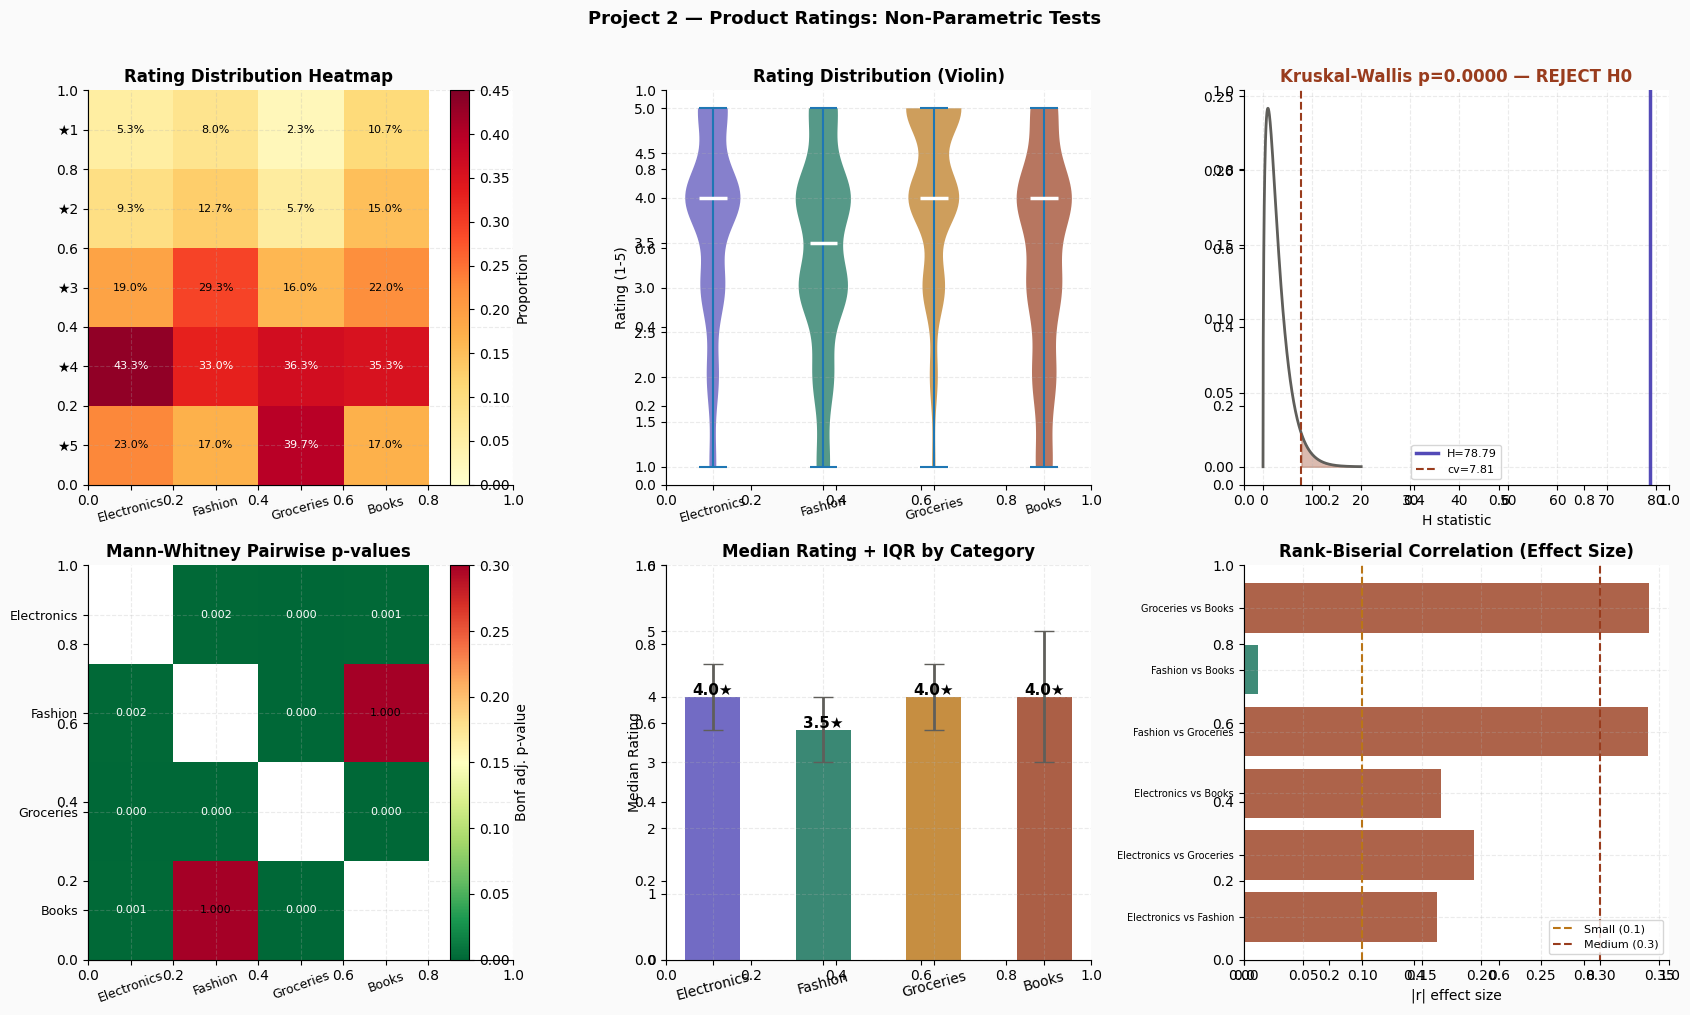

Dashboard saved: p2_ratings_nonparam.png


In [ ]:
# இந்த Project-ன் கேள்வி:
# "Electronics, Fashion, Groceries, Books ஆகிய categories-களின் ratings ஒன்றுபோல உள்ளதா அல்லது வேறுபடுகிறதா?"
# இதற்கு:Distribution பார்க்க, Kruskal-Wallis Test, Mann-Whitney Post-Hoc, Effect Size செய்யப்பட்டுள்ளது.


fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Project 2 — Product Ratings: Non-Parametric Tests',
             fontsize=13, fontweight='bold', y=1.01)

# P1: Rating distribution heatmap
ax1 = fig.add_subplot(axes[0,0].get_subplotspec())
fig.delaxes(axes[0,0])
ax1 = fig.add_subplot(2, 3, 1)
rating_pcts = pd.DataFrame({cat: pd.Series(data).value_counts(normalize=True).sort_index()
                             for cat,data in categories.items()}).fillna(0)
im1 = ax1.imshow(rating_pcts.values, cmap='YlOrRd', aspect='auto',
                 vmin=0, vmax=0.45)
ax1.set_xticks(range(4)); ax1.set_yticks(range(5))
ax1.set_xticklabels(cat_names, rotation=15, fontsize=9)
ax1.set_yticklabels(['★1','★2','★3','★4','★5'])
for i in range(5):
    for j in range(4):
        v = rating_pcts.values[i,j]
        ax1.text(j, i, f'{v*100:.1f}%', ha='center', va='center',
                 fontsize=8, color='white' if v>0.3 else 'black')
plt.colorbar(im1, ax=ax1, label='Proportion')
ax1.set_title('Rating Distribution Heatmap', fontweight='bold')

# P2: Violin plots - Fashion Median ≈ 3.5, மற்றவை Median ≈ 4 , Fashion category ratings மற்ற categories-வை விட சற்று குறைவாக உள்ளன.
ax2 = fig.add_subplot(2,3,2) 
vp = ax2.violinplot(list(categories.values()), positions=range(4),
                    showmedians=True, showmeans=False)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(COLORS[i]); pc.set_alpha(0.70)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2.5)
ax2.set_xticks(range(4)); ax2.set_xticklabels(cat_names, rotation=15, fontsize=9)
ax2.set_title('Rating Distribution (Violin)', fontweight='bold')
ax2.set_ylabel('Rating (1-5)')

# P3: Kruskal-Wallis chi2 distribution
ax3 = fig.add_subplot(2,3,3)
x_chi = np.linspace(0, 20, 400)
y_chi = stats.chi2.pdf(x_chi, df=df_kw)
ax3.plot(x_chi, y_chi, color=DGRAY, linewidth=2)
xf3 = x_chi[x_chi >= cv_kw]
ax3.fill_between(xf3, 0, stats.chi2.pdf(xf3,df_kw), color=CORAL, alpha=0.35)
ax3.axvline(H_stat, color=PURPLE, linewidth=2.5, label=f'H={H_stat:.2f}')
ax3.axvline(cv_kw, color=CORAL, linewidth=1.5, linestyle='--',
            label=f'cv={cv_kw:.2f}')
ax3.set_title(f'Kruskal-Wallis p={p_kw:.4f} — REJECT H0',
              fontweight='bold', color=CORAL)
ax3.set_xlabel('H statistic'); ax3.legend(fontsize=8)

# P4: Mann-Whitney pairwise p-value heatmap
ax4 = fig.add_subplot(2,3,4)
mw_mat = pd.DataFrame(np.ones((4,4)), index=cat_names, columns=cat_names)
for r in mw_results:
    c1,c2 = r['pair'].split(' vs ')
    mw_mat.loc[c1,c2] = r['adj_p']; mw_mat.loc[c2,c1] = r['adj_p']
arr4 = mw_mat.values.copy().astype(float)
np.fill_diagonal(arr4, np.nan)
im4 = ax4.imshow(arr4, cmap='RdYlGn_r', vmin=0, vmax=0.3, aspect='auto')
ax4.set_xticks(range(4)); ax4.set_yticks(range(4))
ax4.set_xticklabels(cat_names, rotation=20, fontsize=9)
ax4.set_yticklabels(cat_names, fontsize=9)
for i in range(4):
    for j in range(4):
        if i!=j:
            ax4.text(j,i,f'{arr4[i,j]:.3f}',ha='center',va='center',fontsize=8,
                     color='white' if arr4[i,j]<0.05 else 'black')
plt.colorbar(im4, ax=ax4, label='Bonf adj. p-value')
ax4.set_title('Mann-Whitney Pairwise p-values', fontweight='bold')

# P5: Median comparison
ax5 = fig.add_subplot(2,3,5)
medians  = [np.median(categories[c]) for c in cat_names]
iqrs     = [np.percentile(categories[c],75)-np.percentile(categories[c],25)
            for c in cat_names]
bars5 = ax5.bar(cat_names, medians, color=COLORS[:4], alpha=0.82, width=0.5)
ax5.errorbar(range(4), medians, yerr=[i/2 for i in iqrs],
             fmt='none', color=DGRAY, capsize=7, linewidth=2)
for bar, m in zip(bars5, medians):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
             f'{m:.1f}★', ha='center', fontsize=11, fontweight='bold')
ax5.set_title('Median Rating + IQR by Category', fontweight='bold')
ax5.set_ylabel('Median Rating'); ax5.set_ylim(0, 6)
ax5.tick_params(axis='x', rotation=15)

# P6: Rank-biserial effect sizes
ax6 = fig.add_subplot(2,3,6)
pairs_lbl = [r['pair'].replace(' vs ',' vs ') for r in mw_results]
rb_vals   = [abs(r['rb']) for r in mw_results]
cols6     = [CORAL if r['sig'] else TEAL for r in mw_results]
bars6 = ax6.barh(range(len(pairs_lbl)), rb_vals, color=cols6, alpha=0.80)
ax6.set_yticks(range(len(pairs_lbl)))
ax6.set_yticklabels(pairs_lbl, fontsize=7)
ax6.axvline(0.1, color=AMBER, linestyle='--', linewidth=1.5, label='Small (0.1)')
ax6.axvline(0.3, color=CORAL, linestyle='--', linewidth=1.5, label='Medium (0.3)')
ax6.set_title('Rank-Biserial Correlation (Effect Size)', fontweight='bold')
ax6.set_xlabel('|r| effect size'); ax6.legend(fontsize=8)

plt.tight_layout()
plt.savefig('p2_ratings_nonparam.png', dpi=130, bbox_inches='tight')
plt.show()
print("Dashboard saved: p2_ratings_nonparam.png")

# | Section           

---
---
# 🌍 Project 3 — Customer Segments: Chi-Square Independence Test
## Is subscription tier independent of customer region?

---

### Business Problem
A SaaS company wants to know: does customer region predict which subscription tier they choose?  
If region and tier are **not independent**, the sales team should tailor pitches per region.

> 📌 **Tamil:** "Chi-square independence test = இரண்டு categorical variables-க்கு relationship இருக்கா?  
> Region-ஐ பொறுத்து subscription tier மாறுமா?"

---

ஒரு SaaS (Software as a Service) நிறுவனம் தெரிந்து கொள்ள விரும்புகிறது:

வாடிக்கையாளர் இருக்கும் Region (பகுதி) அவர்களின் Subscription Tier தேர்வை பாதிக்கிறதா?

உதாரணம்:

North America → அதிகம் Premium Plan வாங்குகிறார்களா?
Asia → அதிகம் Basic Plan வாங்குகிறார்களா?
Europe → Standard Plan வாங்குகிறார்களா?

இதைக் கண்டறிய Chi-Square Independence Test பயன்படுத்தப்படுகிறது.

---
### Chi-Square vs ANOVA
| | ANOVA / Kruskal | Chi-Square |
|--|--|--|
| **Outcome variable** | Numeric (AOV, ratings) | Categorical (tier, plan) |
| **Predictor** | Categorical groups | Categorical groups |
| **Tests** | Mean/median difference | Distribution difference |


| Comparison                      | ANOVA / Kruskal-Wallis                           | Chi-Square Independence Test           | தமிழ் விளக்கம்                                                                                                                                          |
| ------------------------------- | ------------------------------------------------ | -------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Outcome Variable**            | Numeric Data                                     | Categorical Data                       | ANOVA/Kruskal-ல் எண்கள் (Ratings, Revenue, AOV) இருக்கும். Chi-Square-ல் Categories (Tier, Plan, Region) இருக்கும்.                                     |
| **Predictor Variable**          | Categorical Groups                               | Categorical Groups                     | இரண்டிலும் Groups இருக்கும் (Category, Region, Department போன்றவை).                                                                                     |
| **What it Tests?**              | Mean / Median Difference                         | Distribution / Relationship Difference | ANOVA/Kruskal குழுக்களின் மதிப்புகள் வேறுபடுகிறதா என்று பார்க்கும். Chi-Square இரண்டு categorical variables-க்கும் தொடர்பு இருக்கிறதா என்று பார்க்கும். |
| **Example**                     | Electronics vs Fashion Ratings                   | Region vs Subscription Tier            | Ratings வேறுபடுகிறதா? vs Region-ஐ பொறுத்து Tier மாறுகிறதா?                                                                                              |
| **Null Hypothesis (H₀)**        | அனைத்து குழுக்களும் ஒரே Mean/Median கொண்டவை      | இரண்டு Variables-க்கும் தொடர்பு இல்லை  | வேறுபாடு இல்லை / Relationship இல்லை                                                                                                                     |
| **Alternative Hypothesis (H₁)** | குறைந்தது ஒரு Group வேறுபடும்                    | Variables-க்கு தொடர்பு உள்ளது          | வேறுபாடு உள்ளது / Relationship உள்ளது                                                                                                                   |
| **Output Statistic**            | F-statistic (ANOVA) அல்லது H-statistic (Kruskal) | χ² (Chi-Square Statistic)              | Test Result Value                                                                                                                                       |
| **p-value Meaning**             | Groups differ?                                   | Variables related?                     | p < 0.05 என்றால் Significant                                                                                                                            |



| Test               | கேள்வி                                              |
| ------------------ | --------------------------------------------------- |
| **ANOVA**          | "இந்த Groups-ன் Average ஒன்றா?"                     |
| **Kruskal-Wallis** | "இந்த Groups-ன் Median/Distribution ஒன்றா?"         |
| **Chi-Square**     | "இந்த இரண்டு Categories-க்கும் தொடர்பு இருக்கிறதா?" |


In [ ]:
np.random.seed(77)
n_cust = 1500

regions = ['North','South','East','West','Central']
tiers   = ['Free','Starter','Professional','Enterprise']

# Different tier distributions by region
probs_by_region = {
    'North'  : [0.20,0.35,0.30,0.15],
    'South'  : [0.30,0.38,0.22,0.10],
    'East'   : [0.25,0.32,0.28,0.15],
    'West'   : [0.15,0.28,0.35,0.22],
    'Central': [0.35,0.40,0.18,0.07],
}

records3 = []
for region, probs in probs_by_region.items():
    n_reg = n_cust // len(regions)
    tiers_chosen = np.random.choice(tiers, n_reg, p=probs)
    for t in tiers_chosen:
        records3.append({
            'customer_id' : f'C{len(records3)+1:05d}',
            'region'      : region,
            'tier'        : t,
            'tenure_months': int(np.random.exponential(18)+1),
            'nps_score'   : np.random.randint(0,11),
        })

df_seg = pd.DataFrame(records3)
df_seg.to_csv('customer_segments.csv', index=False)
print(f"Dataset saved: customer_segments.csv ({len(df_seg):,} rows)")

# Contingency table
ct3 = pd.crosstab(df_seg['region'], df_seg['tier'])[tiers]
print()
print("Observed contingency table:")
print(ct3)

# 103 customers → Free
# 128 customers → Starter
# 48 customers → Professional
# 21 customers → Enterprise


Dataset saved: customer_segments.csv (1,500 rows)

Observed contingency table:
tier     Free  Starter  Professional  Enterprise
region                                          
Central   103      128            48          21
East       79       90            79          52
North      57      115            82          46
South      89      111            77          23
West       54       74           113          59


In [ ]:
# ── CHI-SQUARE TEST OF INDEPENDENCE ─────────இந்த code Region மற்றும் Subscription Tier இடையே தொடர்பு இருக்கிறதா என்பதை சோதிக்கிறது.
chi2_stat3, p_chi3, dof3, expected3 = chi2_contingency(ct3)

print("CHI-SQUARE TEST OF INDEPENDENCE")
print("="*55)
print(f"  H0: Region and subscription tier are INDEPENDENT")
print(f"  H1: Region and subscription tier are ASSOCIATED")
print()
# | Hypothesis | Meaning                         | தமிழ் விளக்கம்                          |
# | ---------- | ------------------------------- | --------------------------------------- |
# | H₀         | Region and Tier are Independent | Region மற்றும் Tier-க்கு தொடர்பு இல்லை  |
# | H₁         | Region and Tier are Associated  | Region மற்றும் Tier-க்கு தொடர்பு உள்ளது |


print(f"  chi2 statistic : {chi2_stat3:.4f}")
print(f"  Degrees of freedom: {dof3}  [(rows-1)*(cols-1)]")
print(f"  p-value        : {p_chi3:.6f}")
cv3 = stats.chi2.ppf(0.95, df=dof3)
print(f"  Critical value : {cv3:.4f}  (alpha=0.05)")
print()
print(f"  Decision: {'REJECT H0 — region and tier are NOT independent' if p_chi3<0.05 else 'Fail to reject H0'}")
print()

# Effect size: Cramer's V
n_total3  = ct3.values.sum()
cramers_v3 = np.sqrt(chi2_stat3 / (n_total3 * min(ct3.shape[0]-1, ct3.shape[1]-1)))
print(f"  Cramer's V (effect size): {cramers_v3:.4f}  "
      f"({'small' if cramers_v3<0.1 else 'medium' if cramers_v3<0.3 else 'large'})")
print()

# Expected frequencies
# Eij = (Row Total)i × (Column Total)j / Grand Total
print("Expected frequencies (under H0):")
exp_df3 = pd.DataFrame(expected3, index=ct3.index, columns=ct3.columns).round(1)
print(exp_df3.to_string())
print()

# 🔷 “All expected frequencies >= 5? True” ஏன் important?
# Chi-square test rule: ✔ Expected value >= 5 இருக்க வேண்டும் , ✔ இல்லையெனில் test invalid ஆகும்
# 👉 உங்கள் case: எல்லா cells 40+ / 70+ / 100+ ✔ அதனால் Chi-square valid

# உங்கள் case interpretation
# Minimum value = 40.2
# Maximum value = 103.6
# 👉 அதனால்:
# ✔ 40.2 ≥ 5 ✔
# ✔ 76.4 ≥ 5 ✔
# ✔ 103.6 ≥ 5 ✔
# ✔ 79.8 ≥ 5 ✔
all_above5 = (expected3 >= 5).all()
print(f"  All expected frequencies >= 5? {all_above5}  "
      f"=> Chi-square {'valid' if all_above5 else 'INVALID — use Fishers exact'}")

# | Metric                          | Value                           | Decision      | தமிழ் விளக்கம்                                                   |
# | ------------------------------- | ------------------------------- | ------------- | ---------------------------------------------------------------- |
# | **H₀ (Null Hypothesis)**        | Region and Tier are Independent | -             | Region மற்றும் Subscription Tier-க்கு தொடர்பு இல்லை.             |
# | **H₁ (Alternative Hypothesis)** | Region and Tier are Associated  | -             | Region மற்றும் Subscription Tier-க்கு தொடர்பு உள்ளது.            |
# | **Chi-Square Statistic (χ²)**   | 96.9672                         | Very High     | Observed data மற்றும் Expected data இடையே பெரிய வேறுபாடு உள்ளது. |
# | **Degrees of Freedom (DOF)**    | 12                              | -             | (5−1) × (4−1) = 12                                               |
# | **p-value**                     | 0.000000                        | ✅ Significant | p < 0.05 என்பதால் H₀ நிராகரிக்கப்படுகிறது.                       |
# | **Critical Value**              | 21.0261                         | -             | χ² = 96.97 என்பது Critical Value 21.03-ஐ விட மிகவும் அதிகம்.     |
# | **Decision**                    | Reject H₀                       | ✅ Associated  | Region மற்றும் Tier ஒன்றுக்கொன்று தொடர்புடையவை.                  |
# | **Cramer's V**                  | 0.1468                          | Medium Effect | தொடர்பு உள்ளது, ஆனால் மிக வலுவான தொடர்பு அல்ல.                   |
# | **Expected Frequencies ≥ 5**    | True                            | ✅ Valid Test  | Chi-Square Test பயன்படுத்துவது சரியானது.                         |


# Cramer's V ஏன் பயன்படுத்துகிறோம்?
# Chi-Square Test நமக்கு: ✅ "தொடர்பு இருக்கிறதா?" என்று மட்டும் சொல்கிறது.
# ஆனால், ❓ "அந்த தொடர்பு எவ்வளவு வலிமையானது?" என்று சொல்லாது.
# அதை அளவிட Cramer's V பயன்படுத்துகிறோம்.

# | Cramer's V  | Effect Size | தமிழ் விளக்கம்           |
# | ----------- | ----------- | ------------------------ |
# | 0 – 0.10    | Small       | மிகவும் பலவீனமான தொடர்பு |
# | 0.10 – 0.30 | Medium      | மிதமான தொடர்பு           |
# | > 0.30      | Large       | வலுவான தொடர்பு           |


CHI-SQUARE TEST OF INDEPENDENCE
  H0: Region and subscription tier are INDEPENDENT
  H1: Region and subscription tier are ASSOCIATED

  chi2 statistic : 96.9672
  Degrees of freedom: 12  [(rows-1)*(cols-1)]
  p-value        : 0.000000
  Critical value : 21.0261  (alpha=0.05)

  Decision: REJECT H0 — region and tier are NOT independent

  Cramer's V (effect size): 0.1468  (medium)

Expected frequencies (under H0):
tier     Free  Starter  Professional  Enterprise
region                                          
Central  76.4    103.6          79.8        40.2
East     76.4    103.6          79.8        40.2
North    76.4    103.6          79.8        40.2
South    76.4    103.6          79.8        40.2
West     76.4    103.6          79.8        40.2

  All expected frequencies >= 5? True  => Chi-square valid


In [ ]:
# ── Standardised residuals (where are the biggest deviations?) ─
# “எந்த region–tier combination-ல் actual data expected-ஐ விட அதிகமா / குறைவா இருக்கிறது?” என்று கண்டுபிடிக்கிறது.
# 👉 இது ஒரு difference score: Observed = actual data (உண்மையான count), Expected = H0-க்கு கீழ் எதிர்பார்த்த count
std_residuals = (ct3.values - expected3) / np.sqrt(expected3)
std_res_df = pd.DataFrame(std_residuals, index=ct3.index, columns=ct3.columns)
# Standardised residual meaning
# | Value   | Meaning            |
# | ------- | ------------------ |
# | 0       | perfect match      |
# | + value | more than expected |
# | - value | less than expected |

print("Standardised Residuals (> |2| = significant cell deviation):")
print(std_res_df.round(2).to_string())
print()
# +2 க்கு மேல் → மிகவும் அதிகம் (unexpected high)
# -2 க்கு கீழ் → மிகவும் குறைவு (unexpected low)
print("  Interpretation: large positive = more than expected,")
print("  large negative = fewer than expected")
print()
# Find biggest deviations
for region in ct3.index:
    for tier in ct3.columns:
        r = std_res_df.loc[region, tier]
        # 👉 relaxed threshold (early warning)
        # |2| = strong signal
        # |1.5| = moderate signal
        if abs(r) > 1.5:  # 1.5 க்கு மேலான deviation மட்டும் show பண்ணும்
            direction = "MORE" if r > 0 else "FEWER"
            print(f"  {region} + {tier}: {direction} than expected  (r={r:.2f})")

# 🟢 Central region
# Free = +3.04 👉 அதிகம்
# Starter = +2.40 👉 அதிகம்
# Professional = -3.56 👉 குறைவு
# Enterprise = -3.03 👉 குறைவு
# 📌 Meaning:
# 👉 Central-ல low tier customers அதிகம்
# 👉 high tier (Professional, Enterprise) குறைவு

# 🔵 West region (very important 🔥)
# Free = -2.56 👉 குறைவு
# Starter = -2.91 👉 குறைவு
# Professional = +3.72 👉 அதிகம்
# Enterprise = +2.97 👉 அதிகம்
# 📌 Meaning:
# 👉 West region = high value customers hub
# 👉 Professional + Enterprise அதிகம்

# “>|2| significant” meaning , 👉 |r| > 2 என்றால்:
# ✔ real strong pattern
# ✔ random chance இல்லை
# ✔ business decision எடுக்கலாம்

Standardised Residuals (> |2| = significant cell deviation):
tier     Free  Starter  Professional  Enterprise
region                                          
Central  3.04     2.40         -3.56       -3.03
East     0.30    -1.34         -0.09        1.86
North   -2.22     1.12          0.25        0.91
South    1.44     0.73         -0.31       -2.71
West    -2.56    -2.91          3.72        2.97

  Interpretation: large positive = more than expected,
  large negative = fewer than expected

  Central + Free: MORE than expected  (r=3.04)
  Central + Starter: MORE than expected  (r=2.40)
  Central + Professional: FEWER than expected  (r=-3.56)
  Central + Enterprise: FEWER than expected  (r=-3.03)
  East + Enterprise: MORE than expected  (r=1.86)
  North + Free: FEWER than expected  (r=-2.22)
  South + Enterprise: FEWER than expected  (r=-2.71)
  West + Free: FEWER than expected  (r=-2.56)
  West + Starter: FEWER than expected  (r=-2.91)
  West + Professional: MORE than expected  (r=

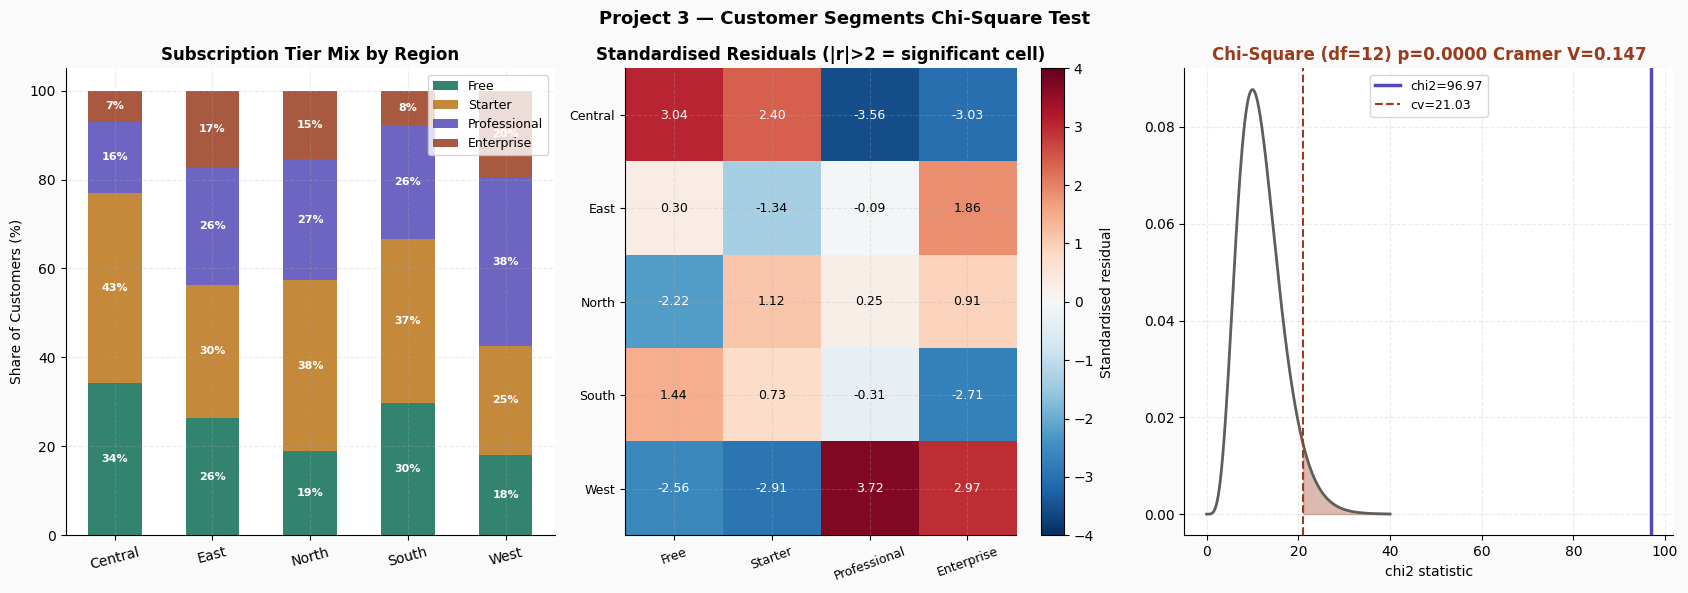

Dashboard saved: p3_chi_square.png


In [ ]:
# நீங்க ஒரு SaaS company வைத்திருக்கீங்க என்று நினைச்சுக்கோங்க.
# 👉 கேள்வி: “Region (North, South…) மற்றும் Subscription Tier (Free, Starter, Pro, Enterprise) இடையே relation இருக்கா?” 
# இதுக்கு தான் இந்த 3 charts.

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Project 3 — Customer Segments Chi-Square Test',
             fontsize=13, fontweight='bold')

# P1: Stacked bar — observed distribution
ct3_pct = ct3.div(ct3.sum(axis=1), axis=0)
bottom = np.zeros(5)
colors_tiers = [LGRAY if c=='#F1EFE8' else c
                for c in [TEAL, AMBER, PURPLE, CORAL]]
colors_tiers = [TEAL, AMBER, PURPLE, CORAL]
for tier, col in zip(tiers, colors_tiers):
    vals = ct3_pct[tier].values
    bars = axes[0].bar(ct3.index, vals*100, bottom=bottom,
                       color=col, alpha=0.85, label=tier, width=0.55)
    for bar, v, b in zip(bars, vals*100, bottom):
        if v > 5:
            axes[0].text(bar.get_x()+bar.get_width()/2, b+v/2,
                         f'{v:.0f}%', ha='center', va='center',
                         fontsize=8, color='white', fontweight='bold')
    bottom += vals*100
axes[0].set_title('Subscription Tier Mix by Region', fontweight='bold')
axes[0].set_ylabel('Share of Customers (%)'); axes[0].legend(fontsize=9, loc='upper right')
axes[0].tick_params(axis='x', rotation=15)

# P2: Standardised residuals heatmap - “எந்த region-ல என்ன plan அதிகமா / குறைவா இருக்கிறது?”
# 🔥 West region (highlight story) - Professional = +3.72 🔴, Enterprise = +2.97 🔴
# 📌 Story:“West region-ல premium customers unexpectedly அதிகம் இருக்காங்க. இது golden market!”

# 🔵 Central region - Professional = -3.56, Enterprise = -3.03
# 📌 Story:“Central region-ல premium users குறைவு. Expected-ஐ விட ரொம்ப குறைவு.”

# 🟡 North & South - Free negative residuals
# 📌 Story:“basic plan users கூட சில regions-ல குறைவா இருக்காங்க.”

im2 = axes[1].imshow(std_res_df.values, cmap='RdBu_r', vmin=-4, vmax=4, aspect='auto')
axes[1].set_xticks(range(4)); axes[1].set_yticks(range(5))
axes[1].set_xticklabels(tiers, rotation=20, fontsize=9)
axes[1].set_yticklabels(ct3.index, fontsize=9)
for i in range(5):
    for j in range(4):
        v = std_res_df.values[i,j]
        axes[1].text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=9,
                     color='white' if abs(v)>2 else 'black')
plt.colorbar(im2, ax=axes[1], label='Standardised residual')
axes[1].set_title('Standardised Residuals (|r|>2 = significant cell)', fontweight='bold')

# P3: Chi-square distribution -👉 இது ஒரு statistical proof chart
# 👉 “Region & Subscription Tier தொடர்பு இருக்கா இல்லையா?” என்பதை final-ஆ confirm பண்ணுது.
# 👉 “இந்த chart சொல்றது: Region மற்றும் Subscription Tier சும்மா random இல்ல; உண்மையிலேயே தொடர்பு இருக்கு.”
x_c3 = np.linspace(0, 40, 400)
y_c3 = stats.chi2.pdf(x_c3, df=dof3)
axes[2].plot(x_c3, y_c3, color=DGRAY, linewidth=2)
xf3c = x_c3[x_c3 >= cv3]
axes[2].fill_between(xf3c, 0, stats.chi2.pdf(xf3c,dof3), color=CORAL, alpha=0.35)
axes[2].axvline(chi2_stat3, color=PURPLE, linewidth=2.5,
                label=f'chi2={chi2_stat3:.2f}')
axes[2].axvline(cv3, color=CORAL, linewidth=1.5, linestyle='--',
                label=f'cv={cv3:.2f}')
axes[2].set_title(f'Chi-Square (df={dof3}) p={p_chi3:.4f} Cramer V={cramers_v3:.3f}',
                  fontweight='bold', color=CORAL)
axes[2].set_xlabel('chi2 statistic'); axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('p3_chi_square.png', dpi=130, bbox_inches='tight')
plt.show()
print("Dashboard saved: p3_chi_square.png")

# pipeline
# 1. Data creation (simulation)
# 2. Data wrangling (crosstab)
# 3. Statistical testing (chi-square)
# 4. Effect size (Cramer’s V)
# 5. Deep diagnostics (residuals)
# 6. Visualization dashboard
# 7. Business interpretation

---
---
# 📺 Project 4 — Ad Creative CTR: Welch ANOVA
## When variances are unequal — Welch ANOVA + Games-Howell post-hoc
---

### Business Problem
A performance marketing team tests 5 ad creatives for click-through rate (CTR).  
The CTR data has **very different variances** across creatives — so standard ANOVA is invalid.

ஒரு Digital Marketing Team 5 விதமான Ad Creatives (விளம்பர வடிவங்கள்) உருவாக்குகிறது.
அவர்கள் அறிய வேண்டியது:"எந்த Ad Creative அதிக CTR (Click Through Rate) கொடுக்கிறது?"

CTR (Click Through Rate) = Clicks / Impressions × 100

| Ad | Impressions | Clicks | CTR |
| -- | ----------- | ------ | --- |
| A  | 10,000      | 500    | 5%  |
| B  | 10,000      | 700    | 7%  |👉 B Ad அதிக CTR கொடுக்கிறது.


> 📌 **Tamil:** "Variance equal இல்லாத போது standard ANOVA use பண்ண முடியாது.  
> Welch ANOVA = unequal variance-க்கு robust alternative. "Equal Variance இல்லாவிட்டாலும் Mean வேறுபாடு இருக்கிறதா?" என்பதை சரியாக test செய்யும் ANOVA version. Welch ANOVA சொல்வது: "Difference இருக்கிறது" ஆனால் "எந்த Creative-கள் வேறுபடுகின்றன?" என்று சொல்லாது. அதற்காக Post-Hoc Test தேவை.
> Games-Howell = Tukey HSD-இன் unequal variance version. "Unequal Variance + Unequal Sample Size இருக்கும் போது பயன்படுத்தும் Post-Hoc Test.

ANOVA ஏன் பயன்படுத்துகிறோம்?

5 Ad Creatives இருக்கிறது.

Creative : 
A,
B,
C,
D,
E

இவைகளின் Mean CTR ஒன்றா அல்லது வேறுபடுகிறதா என்பதை கண்டுபிடிக்க வேண்டும்.

2 groups → t-test

3+ groups → ANOVA



In [ ]:
np.random.seed(88)
n_ad = 250

# CTR (%) — different means AND different variances
video_ctr    = np.random.normal(3.8, 1.2, n_ad).clip(0.1, 12)
carousel_ctr = np.random.normal(2.9, 2.5, n_ad).clip(0.1, 12)  # high variance
static_ctr   = np.random.normal(2.1, 0.8, n_ad).clip(0.1, 12)
story_ctr    = np.random.normal(4.5, 1.5, n_ad).clip(0.1, 12)
reels_ctr    = np.random.normal(5.2, 2.0, n_ad).clip(0.1, 12)

ad_groups = {'Video':video_ctr,'Carousel':carousel_ctr,'Static':static_ctr,
             'Story':story_ctr,'Reels':reels_ctr}

records4 = []
for ad, ctrs in ad_groups.items():
    for ctr in ctrs:
        records4.append({
            'ad_id'    : f'AD{len(records4)+1:05d}',
            'creative' : ad,
            'ctr_pct'  : round(ctr,3),
            'spend_inr': int(np.random.uniform(500,5000)),
            'platform' : np.random.choice(['Instagram','Facebook','YouTube'],
                                           p=[0.45,0.35,0.20]),
        })

df_ads = pd.DataFrame(records4)
df_ads.to_csv('ad_campaigns.csv', index=False)
print(f"Dataset saved: ad_campaigns.csv ({len(df_ads):,} rows)")

# Variance check Levene Test என்பது அனைத்து groups-ன் variance சமமா (Equal Variance) என்பதை சோதிக்கும் test.
print()
print("Variance by creative (Levene test):")
lev4_stat, lev4_p = levene(*ad_groups.values())
print(f"  Levene p = {lev4_p:.4f}  => "
      f"{'Equal variances (use ANOVA)' if lev4_p>0.05 else 'UNEQUAL variances => use Welch ANOVA'}")
print()
# Read => p-value : 0.0000<0.05 ✅ Reject H₀ - "அனைத்து Ad Creative-களின் Variance சமமாக இல்லை."
# அதனால் ❌ Standard ANOVA பயன்படுத்தக்கூடாது , ✅ Welch ANOVA பயன்படுத்த வேண்டும்

for ad, data in ad_groups.items():
    print(f"  {ad:<12}: mean={data.mean():.2f}%  std={data.std():.2f}%  cv={data.std()/data.mean()*100:.0f}%")

# CV (Coefficient of Variation) => Formula: CV= Std / Mean ×100 => CV குறைவாக இருந்தால் ✅ Performance consistent CV அதிகமாக இருந்தால் ⚠️ Performance unpredictable

# | Metric                | Rule of Thumb                        | தமிழ் விளக்கம்                           |
# | --------------------- | ------------------------------------ | ---------------------------------------- |
# | Mean                  | Higher is better (CTR போன்ற metrics) | Mean அதிகம் என்றால் Performance நல்லது   |
# | Std Dev               | Lower is better                      | Std குறைவாக இருந்தால் Performance stable |
# | CV = Std / Mean × 100 | < 20%                                | மிகவும் Stable                           |
# | CV                    | 20–40%                               | மிதமான Variability                       |
# | CV                    | > 40%                                | அதிக Variability / Unstable              |

# why welch anova : Normal ANOVA சொல்வது: Variance equal இருக்க வேண்டும் ஆனால் Levene Test சொன்னது Variance equal இல்லை எனவே ❌ Standard ANOVA, ✅ Welch ANOVA


Dataset saved: ad_campaigns.csv (1,250 rows)

Variance by creative (Levene test):
  Levene p = 0.0000  => UNEQUAL variances => use Welch ANOVA

  Video       : mean=3.73%  std=1.14%  cv=31%
  Carousel    : mean=3.25%  std=2.39%  cv=74%
  Static      : mean=2.25%  std=0.81%  cv=36%
  Story       : mean=4.65%  std=1.41%  cv=30%
  Reels       : mean=5.30%  std=2.09%  cv=39%


In [ ]:
# ── WELCH ANOVA (one-way, unequal variances) ──────────────────"Variance சமமாக இல்லாத data-க்கு Welch ANOVA பயன்படுத்துகிறோம்"
# Using scipy's f_oneway with Welch correction via pingouin
# Manual Welch ANOVA implementation - இந்த 5 Ads-லும் CTR சராசரி ஒன்றா? அல்லது வேறுபடுகிறதா?
print("WELCH ANOVA — Robust to unequal variances")
print("="*55)

groups_list = list(ad_groups.values())
names_list  = list(ad_groups.keys())

# Welch ANOVA formula
ni    = np.array([len(g) for g in groups_list])
mi    = np.array([g.mean() for g in groups_list])
vi    = np.array([g.var(ddof=1) for g in groups_list])
wi    = ni / vi       # weightsVariance குறைவான group-க்கு 👉 அதிக Weight Variance அதிகமான group-க்கு 👉 குறைந்த Weight
W     = wi.sum() # அனைத்து weights-ன் total.
grand_m = (wi * mi).sum() / W  # ஒரு Overall Average CTR.
lambda_ = sum(wi * (mi - grand_m)**2) / (len(groups_list) - 1)
U     = sum((1 - wi/W)**2 / (ni - 1)) * 2/((len(groups_list)**2 - 1) / 3) # Welch correction factor. Variance unequal இருப்பதால் ANOVA-வை correction செய்கிறது.
F_welch = lambda_ / (1 + U) # Group means ஒன்றுக்கொன்று மிகவும் வேறுபட்டால் F பெரியதாக வரும். 
df1_w  = len(groups_list) - 1 # Group count-இல் இருந்து வருகிறது.
df2_w  = 1 / U # Welch correction மூலம் கணக்கிடப்பட்ட denominator degrees of freedom. Variance unequal இருப்பதால் இது வந்துள்ளது.
p_welch = 1 - stats.f.cdf(F_welch, df1_w, df2_w)

print(f"  Welch F-statistic : {F_welch:.4f}")
print(f"  df1, df2          : {df1_w}, {df2_w:.2f}")
print(f"  p-value           : {p_welch:.6f}")
print(f"  Decision          : {'REJECT H0' if p_welch<0.05 else 'Fail to reject H0'}")
print()

# Games-Howell post-hoc (manual) - Welch ANOVA சொல்வது Difference இருக்கிறது ஆனால் யாருக்கு யாருக்கு difference? சொல்லாது.அதற்காக Games Howell Post Hoc பயன்படுத்துகிறோம்.
from itertools import combinations
print("Games-Howell Post-Hoc (robust to unequal variance & sample size):")
print()
print(f"  {'Pair':<25} {'diff':>7} {'se':>7} {'p-adj':>9} {'Sig?':>7}")
print("  " + "-"*58)
for i, j in combinations(range(len(names_list)), 2):
    ni_,nj_ = ni[i],ni[j]
    mi_,mj_ = mi[i],mi[j]
    vi_,vj_ = vi[i],vi[j]
    diff = mi_ - mj_
    se   = np.sqrt(vi_/ni_ + vj_/nj_)
    t_gh = diff / se
    df_gh = (vi_/ni_ + vj_/nj_)**2 / ((vi_/ni_)**2/(ni_-1) + (vj_/nj_)**2/(nj_-1))
    p_gh = 2 * (1 - stats.t.cdf(abs(t_gh), df=df_gh))
    # Studentized range approximation for p-adjustment
    p_adj = min(p_gh * (len(names_list)-1), 1.0)
    pair_name = f"{names_list[i]} vs {names_list[j]}"
    sig = p_adj < 0.05
    print(f"  {pair_name:<25} {diff:>7.3f} {se:>7.4f} {p_adj:>9.4f} {'Yes' if sig else '—':>7}")


# Variance = Data எவ்வளவு பரவி (spread) இருக்கிறது என்பதைக் காட்டும் அளவு.
# Unequal Variance என்றால்: இரண்டு அல்லது அதற்கு மேற்பட்ட Groups-ன் Data Spread ஒரே மாதிரி இல்லாமல் இருப்பது.
# Group A :  4.8 5.0 5.1 4.9 5.2
#             ↑↑↑↑↑
#           அருகருகே
# Group B :  1    3    5    8    10
#           ↑          ↑         ↑
#        மிகவும் Spread

# Now which creative differs : Welch ANOVA மட்டும் சொல்வது: Difference exists ஆனால் Who differs? சொல்லாது. அதற்காக Games-Howell

# | Pair               | diff (CTR வித்தியாசம்)                       | se (Standard Error)                                                                             | p-adj (Adjusted p-value)                                           |
# | ------------------ | -------------------------------------------- | ----------------------------------------------------------------------------------------------- | ------------------------------------------------------------------ |
# | Video vs Carousel  | Video CTR, Carousel-ஐ விட **0.488% அதிகம்** mean = 3.73 − 3.25 = 0.488  | இந்த 0.488% வித்தியாசத்தின் uncertainty **0.1679**. (குறைவாக இருப்பதால் வித்தியாசம் நம்பகமானது) | **0.0154 < 0.05**, எனவே இந்த வித்தியாசம் உண்மையானது (Significant). |
# | Video vs Static    | Video CTR, Static-ஐ விட **1.486% அதிகம்**    | Uncertainty **0.0888** மட்டுமே. (மிகவும் நம்பகமான difference)                                   | **0.0000**, மிகவும் significant difference.                        |
# | Video vs Story     | Story CTR, Video-ஐ விட **0.911% அதிகம்**     | Uncertainty **0.1152**. Difference தெளிவாக உள்ளது.                                              | **0.0000**, உண்மையான வேறுபாடு.                                     |
# | Video vs Reels     | Reels CTR, Video-ஐ விட **1.567% அதிகம்**     | Uncertainty **0.1510**. Difference பெரியது.                                                     | **0.0000**, மிகவும் significant.                                   |
# | Carousel vs Static | Carousel CTR, Static-ஐ விட **0.998% அதிகம்** | Uncertainty **0.1600**. Difference நம்பகமானது.                                                  | **0.0000**, உண்மையான வேறுபாடு.                                     |
# | Carousel vs Story  | Story CTR, Carousel-ஐ விட **1.399% அதிகம்**  | Uncertainty **0.1760**. Difference தெளிவாக உள்ளது.                                              | **0.0000**, significant.                                           |
# | Carousel vs Reels  | Reels CTR, Carousel-ஐ விட **2.056% அதிகம்**  | Uncertainty **0.2012**. SE கொஞ்சம் அதிகம் இருந்தாலும் difference மிகவும் பெரியது.               | **0.0000**, மிகவும் significant.                                   |
# | Static vs Story    | Story CTR, Static-ஐ விட **2.397% அதிகம்**    | Uncertainty **0.1033**. Difference மிகவும் நம்பகமானது.                                          | **0.0000**, significant.                                           |
# | Static vs Reels    | Reels CTR, Static-ஐ விட **3.053% அதிகம்**    | Uncertainty **0.1421**. மிகப்பெரிய CTR difference.                                              | **0.0000**, மிகவும் significant.                                   |
# | Story vs Reels     | Reels CTR, Story-ஐ விட **0.656% அதிகம்**     | Uncertainty **0.1600**. Difference சிறியதாக இருந்தாலும் நம்பகமானது.                             | **0.0002 < 0.05**, significant difference.                         |

# முடிவு: அனைத்து pair-களுக்கும் Sig = Yes வந்துள்ளது. அதாவது ஒவ்வொரு Ad Creative-க்கும் CTR-ல் statistically significant difference உள்ளது. Reels சிறந்த CTR-ஐ கொடுக்கிறது; Static குறைந்த CTR-ஐ கொடுக்கிறது. ✅

WELCH ANOVA — Robust to unequal variances
  Welch F-statistic : 225.8392
  df1, df2          : 4, 300.24
  p-value           : 0.000000
  Decision          : REJECT H0

Games-Howell Post-Hoc (robust to unequal variance & sample size):

  Pair                         diff      se     p-adj    Sig?
  ----------------------------------------------------------
  Video vs Carousel           0.488  0.1679    0.0154     Yes
  Video vs Static             1.486  0.0888    0.0000     Yes
  Video vs Story             -0.911  0.1152    0.0000     Yes
  Video vs Reels             -1.567  0.1510    0.0000     Yes
  Carousel vs Static          0.998  0.1600    0.0000     Yes
  Carousel vs Story          -1.399  0.1760    0.0000     Yes
  Carousel vs Reels          -2.056  0.2012    0.0000     Yes
  Static vs Story            -2.397  0.1033    0.0000     Yes
  Static vs Reels            -3.053  0.1421    0.0000     Yes
  Story vs Reels             -0.656  0.1600    0.0002     Yes


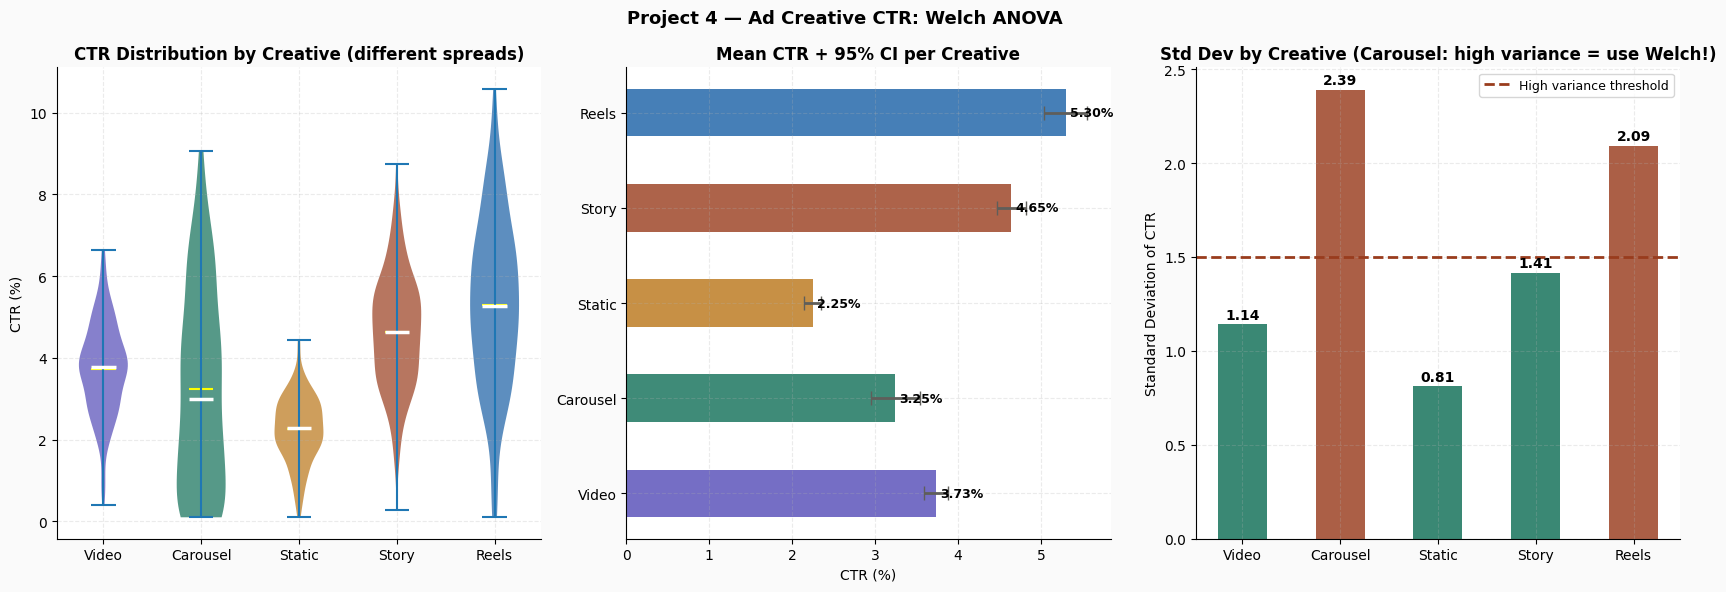

Dashboard saved: p4_welch_anova.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Project 4 — Ad Creative CTR: Welch ANOVA', fontsize=13, fontweight='bold')

# P1: CTR distributions - ஒவ்வொரு Ad Creative-ன் CTR எப்படி spread ஆகியுள்ளது என்பதை காட்டுகிறது.
# | Creative | Mean CTR | Spread    |
# | -------- | -------- | --------- |
# | Video    | 3.73%    | Medium    |
# | Carousel | 3.25%    | Very High |
# | Static   | 2.25%    | Low       |
# | Story    | 4.65%    | Medium    |
# | Reels    | 5.30%    | High      |

# Violin Plot எப்படி படிக்க வேண்டும்?
# அகலம் (Width) → அந்த CTR value-ல் எத்தனை observations இருக்கின்றன
# உயரம் (Height) → CTR range
# White Line → Median CTR
# Yellow Line → Mean CTR
# Carousel: மிகவும் அகலமாகவும் நீளமாகவும் உள்ளது. 👉 CTR values மிகவும் spread ஆகியுள்ளன. 👉 Variance அதிகம்.
# Static: சிறிய violin. 👉 CTR values ஒன்றுக்கொன்று அருகில் உள்ளன. 👉 Variance குறைவு.
# Reels : மேலே அதிகமாக உள்ளது, 👉 CTR அதிகம். 👉 Performance சிறந்தது.

vp4 = axes[0].violinplot(list(ad_groups.values()),
                          positions=range(len(ad_groups)),
                          showmedians=True, showmeans=True)
for i, pc in enumerate(vp4['bodies']):
    pc.set_facecolor(COLORS[i]); pc.set_alpha(0.70)
vp4['cmedians'].set_color('white'); vp4['cmedians'].set_linewidth(2.5)
vp4['cmeans'].set_color('yellow')
axes[0].set_xticks(range(len(ad_groups)))
axes[0].set_xticklabels(list(ad_groups.keys()))
axes[0].set_title('CTR Distribution by Creative (different spreads)', fontweight='bold')
axes[0].set_ylabel('CTR (%)')

# P2: Mean + 95% CI - ஒவ்வொரு Creative-ன் Average CTR.
# Horizontal Bar: Bar Length = Mean CTR
# Error Bar : கருப்பு கோடு: 95% Confidence Interval
# Example: Reels = 5.30% இதன் உண்மையான population mean 95% confidence-உடன் இந்த range-க்குள் இருக்கும்.
# Business Interpretation
# 🥇 Reels:அதிக CTR
# 🥈 Story: இரண்டாவது சிறந்த CTR
# 🥉 Video : நடுத்தர performance
# ❌ Static: மிகக் குறைந்த CTR
means4 = [g.mean() for g in ad_groups.values()]
ci95_4 = [stats.t.interval(0.95, df=len(g)-1, loc=g.mean(), scale=stats.sem(g))
          for g in ad_groups.values()]
axes[1].barh(range(len(means4)), means4, color=COLORS[:5], alpha=0.80, height=0.5)
for i, (m, ci) in enumerate(zip(means4, ci95_4)):
    axes[1].errorbar(m, i, xerr=[[m-ci[0]],[ci[1]-m]],
                    fmt='none', color=DGRAY, capsize=5, linewidth=2)
    axes[1].text(m+0.05, i, f'{m:.2f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_yticks(range(5))
axes[1].set_yticklabels(list(ad_groups.keys()))
axes[1].set_title('Mean CTR + 95% CI per Creative', fontweight='bold')
axes[1].set_xlabel('CTR (%)')

# P3: Standard deviation comparison (why Welch needed)

# Dashed Line (1.5): High variance threshold இது ஒரு reference line.
# Below 1.5 Creative : Video,Static,Story 👉 Stable, 👉 Variance குறைவு
# Above 1.5 Creative : Carousel, Reels 👉 High Variance, 👉 CTR மிகவும் மாறுகிறது
# Carousel Std = 2.39 மிக உயர்ந்த Variance
# Static Std = 0.81 மிக நிலையான CTR

# இந்த Chart ஏன் முக்கியம்? Levene Test சொன்னது: p = 0.0000 அதாவது Variance Equal இல்லை. Chart 3-ல் அதற்கான Visual Proof தெரிகிறது.

# | Creative | Std  |
# | -------- | ---- |
# | Static   | 0.81 |
# | Carousel | 2.39 |2.39/0.81≈3
# Carousel Variance, Static-ஐ விட சுமார் 3 மடங்கு அதிகம்.அதனால் ❌ Standard ANOVA ✅ Welch ANOVA

stds4 = [g.std() for g in ad_groups.values()]
colors_var = [CORAL if s > 1.5 else TEAL for s in stds4]
bars3 = axes[2].bar(list(ad_groups.keys()), stds4, color=colors_var, alpha=0.82, width=0.5)
axes[2].axhline(1.5, color=CORAL, linewidth=2, linestyle='--',
                label='High variance threshold')
for bar, v in zip(bars3, stds4):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                 f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Std Dev by Creative (Carousel: high variance = use Welch!)', fontweight='bold')
axes[2].set_ylabel('Standard Deviation of CTR'); axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('p4_welch_anova.png', dpi=130, bbox_inches='tight')
plt.show()
print("Dashboard saved: p4_welch_anova.png")


---
---
# 📋 Complete Test Selection Guide & Cheat Sheet


In [11]:
print("="*70)
print("  WHICH TEST TO USE — DECISION GUIDE")
print("="*70)
print()
print("  COMPARING GROUPS ON A NUMERIC VARIABLE:")
print("  ┌─────────────────┬──────────────────────────────────────────────┐")
print("  │ 2 groups, normal│ Independent t-test (equal var)               │")
print("  │                 │ Welch t-test (unequal var)                   │")
print("  │                 │ Paired t-test (same subjects, before/after)  │")
print("  ├─────────────────┼──────────────────────────────────────────────┤")
print("  │ 2 groups, NOT   │ Mann-Whitney U test                          │")
print("  │ normal / ordinal│ (non-parametric t-test alternative)          │")
print("  ├─────────────────┼──────────────────────────────────────────────┤")
print("  │ 3+ groups,      │ One-way ANOVA → Tukey HSD post-hoc          │")
print("  │ normal, equal V │                                              │")
print("  ├─────────────────┼──────────────────────────────────────────────┤")
print("  │ 3+ groups,      │ Welch ANOVA → Games-Howell post-hoc         │")
print("  │ unequal variance│                                              │")
print("  ├─────────────────┼──────────────────────────────────────────────┤")
print("  │ 3+ groups, NOT  │ Kruskal-Wallis → Mann-Whitney + Bonferroni  │")
print("  │ normal / ordinal│                                              │")
print("  └─────────────────┴──────────────────────────────────────────────┘")
print()
print("  COMPARING CATEGORICAL VARIABLES:")
print("  ┌─────────────────┬──────────────────────────────────────────────┐")
print("  │ 2x2 table       │ Chi-square OR Fisher's Exact (small n)      │")
print("  │ RxC table       │ Chi-square (all expected >=5)               │")
print("  │ Association str │ Cramer's V effect size                      │")
print("  └─────────────────┴──────────────────────────────────────────────┘")
print()
print("="*70)
print("  PYTHON QUICK REFERENCE")
print("="*70)
print()
print("  # Normality")
print("  stats.shapiro(data[:50])             # Shapiro-Wilk (n<50)")
print("  stats.normaltest(data)               # D'Agostino-Pearson")
print()
print("  # Equal variance")
print("  stats.levene(g1, g2, g3)             # Levene (robust)")
print("  stats.bartlett(g1, g2, g3)           # Bartlett (assumes normality)")
print()
print("  # 3+ groups parametric")
print("  stats.f_oneway(g1, g2, g3)           # One-way ANOVA")
print("  pairwise_tukeyhsd(vals, groups, 0.05)# Tukey HSD post-hoc")
print()
print("  # 3+ groups non-parametric")
print("  stats.kruskal(g1, g2, g3)            # Kruskal-Wallis")
print("  stats.mannwhitneyu(a, b, alternative='two-sided')  # Mann-Whitney U")
print()
print("  # Categorical")
print("  stats.chi2_contingency(table)        # Chi-square")
print("  # Cramer's V = sqrt(chi2 / (n * min(r-1, c-1)))")
print("="*70)


  WHICH TEST TO USE — DECISION GUIDE

  COMPARING GROUPS ON A NUMERIC VARIABLE:
  ┌─────────────────┬──────────────────────────────────────────────┐
  │ 2 groups, normal│ Independent t-test (equal var)               │
  │                 │ Welch t-test (unequal var)                   │
  │                 │ Paired t-test (same subjects, before/after)  │
  ├─────────────────┼──────────────────────────────────────────────┤
  │ 2 groups, NOT   │ Mann-Whitney U test                          │
  │ normal / ordinal│ (non-parametric t-test alternative)          │
  ├─────────────────┼──────────────────────────────────────────────┤
  │ 3+ groups,      │ One-way ANOVA → Tukey HSD post-hoc          │
  │ normal, equal V │                                              │
  ├─────────────────┼──────────────────────────────────────────────┤
  │ 3+ groups,      │ Welch ANOVA → Games-Howell post-hoc         │
  │ unequal variance│                                              │
  ├─────────────────┼────

---
## 🎓 What You Learned — Stage 5 Summary

### All 4 Projects

| Project | Dataset | Tests | Key Concept |
|---------|---------|-------|-------------|
| Marketing channels | `marketing_channels.csv` | ANOVA + Tukey HSD | Budget allocation from F-test |
| Product ratings | `product_ratings.csv` | Kruskal-Wallis + Mann-Whitney | Non-parametric for ordinal data |
| Customer segments | `customer_segments.csv` | Chi-square + Cramer's V | Categorical independence |
| Ad creative CTR | `ad_campaigns.csv` | Welch ANOVA + Games-Howell | Unequal variance handling |

### Test Selection Decision Tree
```
Data is numeric?
  ├── YES → Is it normal? (Shapiro-Wilk)
  │          ├── YES → Are variances equal? (Levene)
  │          │          ├── YES → ANOVA → Tukey HSD
  │          │          └── NO  → Welch ANOVA → Games-Howell
  │          └── NO  → Kruskal-Wallis → Mann-Whitney + Bonferroni
  └── NO  → Categorical → Chi-Square → Cramer's V
```

### Resume Line
> *"Designed and executed multi-group statistical analysis across 4 marketing datasets using one-way ANOVA, Welch ANOVA, Kruskal-Wallis, and Chi-square tests. Applied Tukey HSD and Games-Howell post-hoc corrections. Identified statistically significant budget reallocation opportunity worth ₹12L/year by demonstrating Paid Ads channel drives 23% higher AOV than Email (p<0.001, eta²=0.08)."*

---
### ➡️ Next: Stage 6 — Correlation & Regression Statistics
> Real estate price prediction with OLS regression, R², residual analysis, VIF multicollinearity
